In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
pd.set_option('display.max_colwidth', None)
import matplotlib
from adjustText import adjust_text

matplotlib.rcParams['pdf.fonttype'] = 42

In [3]:
s34fcsc_contrast_table = pd.read_csv('/Users/selammehreteab/Downloads/101325.wtdmsovsmtcsc.dpsi.tsv', sep = "\t")
s34fdmso_contrast_table = pd.read_csv('/Users/selammehreteab/Downloads/101325.wtdmsovsmtdmso.dpsi.tsv', sep = "\t")
wtcsc_contrast_table = pd.read_csv('/Users/selammehreteab/Downloads/101325.wtdmsovswtcsc.dpsi.tsv', sep = "\t")
s34fdmso_contrast_table

,inclusion_exclusion,contains_novel_or_only_known_junctions,as_event_type,gene_name,gene_coordinates,strand,W1D2.S24_wtdmso_b1,W1D3.S32_wtdmso_b1,W2D2.S22_wtdmso_b1,W2D3.S30_wtdmso_b1,M1D2.S28_mtdmso_b1,M1D3.S36_mtdmso_b1,M2D2.S26_mtdmso_b1,lr,padj,dpsi
0,inclusion,N,alternative_acceptor,KRBA2,chr17:8349240-8377522,.,0.034,0.034,0.034,0.034,0.949,0.949,0.949,268.92,3.710000e-56,91.5
1,inclusion,K,intron_retention,CTNNB1,chr3:41239355-41239818,+,0.353,0.353,0.353,0.353,0.760,0.760,0.760,217.12,3.660000e-45,40.7
2,inclusion,K,intron_retention,FN1,chr2:215372016-215372108,-,0.229,0.229,0.229,0.229,0.133,0.133,0.133,189.15,3.090000e-39,-9.6
3,inclusion,K,alternative_acceptor,FN1,chr2:215372376-215373321,-,0.795,0.795,0.795,0.795,0.550,0.550,0.550,163.82,7.870000e-34,-24.5
4,inclusion,N,cassette,RPS24,chr10:78040204-78040225,+,0.403,0.403,0.403,0.403,0.115,0.115,0.115,118.38,5.460000e-24,-28.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,inclusion,K,cassette,SUOX,chr12:55999333-55999458,+,0.388,0.388,0.388,0.388,0.148,0.148,0.148,8.04,5.000000e-02,-24.0
1736,inclusion,K,intron_retention,FBXW5,chr9:136941685-136942045,-,0.077,0.077,0.077,0.077,0.037,0.037,0.037,8.04,5.000000e-02,-4.0
1737,inclusion,K,intron_retention,RAD23B,chr9:107283310-107283526,+,0.960,0.960,0.960,0.960,0.992,0.992,0.992,8.04,5.000000e-02,3.2
1738,inclusion,N,cassette,PHF2,chr9:93659511-93659600,+,0.881,0.881,0.881,0.881,0.979,0.979,0.979,8.04,5.000000e-02,9.8


In [4]:
# s34f csc
s34fcsc_sorted = s34fcsc_contrast_table.sort_values(by='dpsi')
s34fcsc_filtered = s34fcsc_sorted[s34fcsc_sorted['dpsi'].abs() >= 10]
exclude_event_types = ['jcn_only_AA', 'jcn_only_AD', s34fcsc_filtered[(s34fcsc_filtered['as_event_type'] == 'intron_retention') & (s34fcsc_filtered['contains_novel_or_only_known_junctions'] == 'N')]]
s34fcsc_filtered = s34fcsc_filtered[~s34fcsc_filtered['as_event_type'].isin(exclude_event_types)]



# s34f dmso
s34fdmso_sorted = s34fdmso_contrast_table.sort_values(by='dpsi')
s34fdmso_filtered = s34fdmso_sorted[s34fdmso_sorted['dpsi'].abs() >= 10]
exclude_event_types = ['jcn_only_AA', 'jcn_only_AD', s34fdmso_filtered[(s34fdmso_filtered['as_event_type'] == 'intron_retention') & (s34fdmso_filtered['contains_novel_or_only_known_junctions'] == 'N')]]
s34fdmso_filtered = s34fdmso_filtered[~s34fdmso_filtered['as_event_type'].isin(exclude_event_types)]

# wt csc
wtcsc_sorted = wtcsc_contrast_table.sort_values(by='dpsi')
wtcsc_filtered = wtcsc_sorted[wtcsc_sorted['dpsi'].abs() >= 10]
exclude_event_types = ['jcn_only_AA', 'jcn_only_AD', wtcsc_filtered[(wtcsc_filtered['as_event_type'] == 'intron_retention') & (wtcsc_filtered['contains_novel_or_only_known_junctions'] == 'N')]]
wtcsc_filtered = wtcsc_filtered[~wtcsc_filtered['as_event_type'].isin(exclude_event_types)]


### After manually filling in the nan values then go in and filter out genes that are not significant/event types that we don't really care about

In [49]:
wtcsc = wtcsc_filtered['gene_name'].dropna()
wtcsc.to_csv("/Users/selammehreteab/Downloads/v2_wtcsc_dpsi_sg_gsea_unranked.txt",index=False,header=False)

mtcsc = s34fcsc_filtered['gene_name'].dropna()
mtcsc.to_csv("/Users/selammehreteab/Downloads/v2_mtcsc_dpsi_sg_gsea_unranked.txt",index=False,header=False)

mtdmso = s34fdmso_filtered['gene_name'].dropna()
mtdmso.to_csv("/Users/selammehreteab/Downloads/v2_mtdmso_dpsi_sg_gsea_unranked.txt",index=False,header=False)
mtcsc

229       KRT6C
108        WSB1
191       CASP8
129       CASP8
4       SMARCA1
         ...   
1491       FLNA
277     ZC3H11A
36      LRRFIP1
89      TRIM16L
156        WSB1
Name: gene_name, Length: 1116, dtype: object

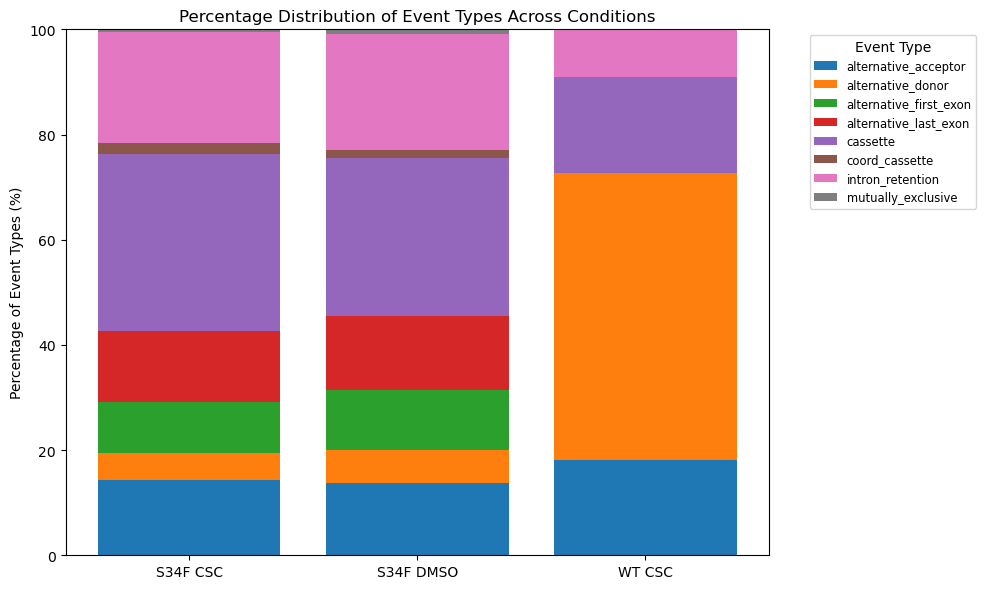

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# s34fcsc_filtered, s34fdmso_filtered, wtcsc_filtered

# Count occurrences of each event type for each condition
s34fcsc_counts = s34fcsc_filtered['as_event_type'].value_counts()
s34fdmso_counts = s34fdmso_filtered['as_event_type'].value_counts()
wtcsc_counts = wtcsc_filtered['as_event_type'].value_counts()

all_counts = pd.DataFrame({
    "S34F CSC": s34fcsc_counts,
    "S34F DMSO": s34fdmso_counts,
    "WT CSC": wtcsc_counts
}).fillna(0)

# Convert counts to percentages
all_percentages = all_counts.div(all_counts.sum(axis=0), axis=1) * 100

categories = all_percentages.index
conditions = all_percentages.columns
colors = plt.cm.tab10(range(len(categories)))  

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = range(len(conditions))  # X positions for the bars
bottom_values = [0] * len(conditions)  # Initial bottom values for stacking

for category, color in zip(categories, colors):
    values = all_percentages.loc[category].values
    ax.bar(x_positions, values, bottom=bottom_values, label=category, color=color)
    bottom_values = [bottom + value for bottom, value in zip(bottom_values, values)]

ax.set_xticks(x_positions)
ax.set_xticklabels(conditions)
ax.set_ylabel("Percentage of Event Types (%)")
ax.set_title("Percentage Distribution of Event Types Across Conditions")
ax.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax.set_ylim(0, 100)  # Since percentages range from 0 to 100

plt.tight_layout()
# plt.show()
# plt.savefig('/Users/selammehreteab/Desktop/Juncbase_try2/Percentage Distribution of Event Types Across Conditions.png') 

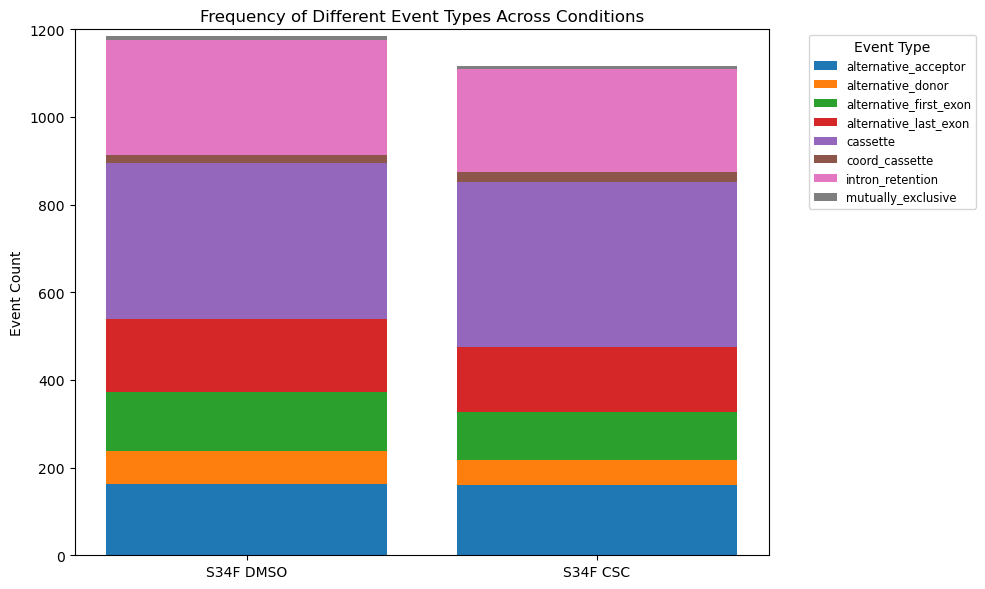

In [8]:
#this is with cindy's filtering
# s34fcsc_filtered, s34fdmso_filtered, wtcsc_filtered

s34fcsc_counts = s34fcsc_filtered['as_event_type'].value_counts()
s34fdmso_counts = s34fdmso_filtered['as_event_type'].value_counts()
# wtcsc_counts = wtcsc_filtered['as_event_type'].value_counts()

all_counts = pd.DataFrame({
    "S34F DMSO": s34fdmso_counts,
    "S34F CSC": s34fcsc_counts,
    # "WT CSC": wtcsc_counts
}).fillna(0)

categories = all_counts.index
conditions = all_counts.columns
colors = plt.cm.tab10(range(len(categories)))  

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = range(len(conditions))  # X positions for the bars
bottom_values = [0] * len(conditions)  # Initial bottom values for stacking

for category, color in zip(categories, colors):
    values = all_counts.loc[category].values
    ax.bar(x_positions, values, bottom=bottom_values, label=category, color=color)
    bottom_values = [bottom + value for bottom, value in zip(bottom_values, values)]

ax.set_xticks(x_positions)
ax.set_xticklabels(conditions)
ax.set_ylabel("Event Count")
ax.set_title("Frequency of Different Event Types Across Conditions")
ax.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax.set_ylim(0, 1200)

plt.tight_layout()
# plt.show()
# plt.savefig("Downloads/dpsi_volcano_s34flacz.pdf", format='pdf', transparent=True)
# 
plt.savefig('/Users/selammehreteab/Downloads/Juncv2_Frequency_of_Different_Event_Types_Across_Conditions.pdf', format = 'pdf', dpi = 1200)


In [14]:
s34fcsc_filtereds_name = s34fcsc_filtered[s34fcsc_filtered['as_event_type'] == 'alternative_first_exon']
sets = s34fcsc_filtereds_name['gene_name'].to_list()
s34fcsc_filtereds_sets =set(sets)
s34fcsc_filtereds_sets 

{'AACS',
 'AC118549.1',
 'AC139256.3',
 'AKT1',
 'ARFRP1',
 'ATXN2',
 'BACH1',
 'BX890604.2',
 'C11orf80',
 'C17orf75',
 'CBFB',
 'CCND3',
 'CD44',
 'CGB7',
 'CLTCL1',
 'CTTN',
 'DDX59',
 'DHX38',
 'DMKN',
 'DNAJC5',
 'DYRK4',
 'EPG5',
 'ERBIN',
 'ETV4',
 'FADS2',
 'FIP1L1',
 'FKBP9P1',
 'FN1',
 'GGA1',
 'GNAS',
 'HMGCL',
 'HNRNPR',
 'IGFBP2',
 'KPTN',
 'KRT6C',
 'LIG1',
 'LMBR1L',
 'LRRFIP1',
 'MAGED2',
 'MAGOHB',
 'MCM7',
 'MECP2',
 'MED15',
 'MFF',
 'MTERF3',
 'NADSYN1',
 'NFKB2',
 'OPA1',
 'PABPC4',
 'PARD3',
 'PBX3',
 'PCDHA11',
 'PCM1',
 'PDCD5',
 'PGAP2',
 'PLA2G6',
 'PLEK2',
 'PLSCR3',
 'PPCDC',
 'PRDM1',
 'PYGO2',
 'RCC1',
 'RGS3',
 'RIPK2',
 'RIT1',
 'SAFB2',
 'SAP30L',
 'SEC14L2',
 'SEC31A',
 'SH3KBP1',
 'SHMT2',
 'SHROOM2',
 'SIN3B',
 'SINHCAF',
 'SLAIN2',
 'SLC20A2',
 'SMAD3',
 'SPEG',
 'SQSTM1',
 'SREBF1',
 'SRPK2',
 'SUN2',
 'SUPT5H',
 'TACC2',
 'TANGO2',
 'THAP9-AS1',
 'TM7SF3',
 'TMEM129',
 'TMEM91',
 'TPCN1',
 'TRAK1',
 'TRIM7',
 'UBE2A',
 'UBE2Q2',
 'URGCP',
 'URGCP-

In [15]:
s34fdmso_filtereds_name = s34fdmso_filtered[s34fdmso_filtered['as_event_type'] == 'alternative_first_exon']
dmso_sets = s34fdmso_filtereds_name['gene_name'].to_list()
s34fdmso_filtereds_sets =set(dmso_sets)
s34fdmso_filtereds_sets

{'AACS',
 'AC118549.1',
 'ADGRG6',
 'AKT1',
 'ARAP1',
 'ARHGAP12',
 'ARHGEF3',
 'ASXL1',
 'ATG9A',
 'ATXN2',
 'ATXN2L',
 'BBIP1',
 'BCAR1',
 'BCL2L1',
 'BX890604.2',
 'C17orf75',
 'CASC4',
 'CBFB',
 'CCDC112',
 'CCDC85C',
 'CD44',
 'CLASP1',
 'CLTCL1',
 'COQ7',
 'CTDNEP1',
 'CYREN',
 'DCAF11',
 'DDR1',
 'DHX38',
 'DMKN',
 'DNAJC5',
 'DYRK4',
 'ELOVL1',
 'ENTPD6',
 'EPN3',
 'ERBIN',
 'EXTL3',
 'FADS2',
 'FAM174C',
 'FAM53B',
 'FAS',
 'FBXW7',
 'FIP1L1',
 'FLT3LG',
 'GINS1',
 'GNAS',
 'HMGCL',
 'HNRNPR',
 'IFITM1',
 'KPTN',
 'KRT6C',
 'LHFPL2',
 'LIG1',
 'LIMS1',
 'LMBR1L',
 'LRRFIP1',
 'LTBR',
 'MAGED2',
 'MAGOHB',
 'MCC',
 'MECP2',
 'MED15',
 'MFF',
 'MPRIP',
 'MRNIP',
 'MST1R',
 'NADSYN1',
 'NCOR2',
 'NECAB3',
 'NMRK1',
 'NOL4L',
 'OPA1',
 'PABPC4',
 'PARD3',
 'PBX3',
 'PCM1',
 'PDCD5',
 'PDS5B',
 'PGAP2',
 'PHLDB2',
 'PIGF',
 'PLA2G6',
 'PLEC',
 'PLEK2',
 'PML',
 'RASAL2',
 'RBM39',
 'RFFL',
 'RGL2',
 'RGS3',
 'RTN2',
 'S100A13',
 'SEC14L2',
 'SEC31A',
 'SESN1',
 'SHMT2',
 'SIAH1',
 

In [20]:
s34fdmso_only = s34fdmso_filtereds_sets - s34fcsc_filtereds_sets
# s34fdmso_only
len(s34fdmso_only)

74

In [8]:
s34fcsc_counts

as_event_type
cassette                  376
intron_retention          236
alternative_acceptor      160
alternative_last_exon     150
alternative_first_exon    108
alternative_donor          58
coord_cassette             22
mutually_exclusive          6
Name: count, dtype: int64

In [7]:
s34fdmso_counts

as_event_type
cassette                  355
intron_retention          262
alternative_last_exon     166
alternative_acceptor      162
alternative_first_exon    136
alternative_donor          75
coord_cassette             19
mutually_exclusive         10
Name: count, dtype: int64

In [43]:
# s34fdmso_filtered = s34fdmso_filtered.loc[s34fdmso_filtered['GeneName'] == 'CCND3']
s34fdmso_filtered.to_csv('/Users/selammehreteab/Downloads/S34FDMSO_significant_splicingevents.csv')
s34fcsc_filtered.to_csv('/Users/selammehreteab/Downloads/S34FCSC_significant_splicingevents.csv')

## Identifying the genes with alternative first exon events that are alternatively spliced in S34F DMSO and not in S34F CSC

## will make volcano plots below

In [8]:
dflist = [s34fcsc_filtered, s34fdmso_filtered, wtcsc_filtered]


for df in dflist:
    df['neglogp'] = -np.log10(df['padj'])

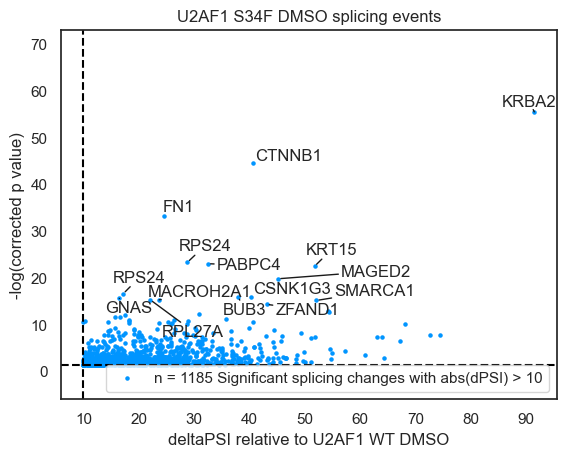

In [20]:
# specify coordinates for significant dots and coordinates for labeling gene names
sns.set_theme(style='white')

#dflist = [ s34fcsc_jbPSI, s34fdmso_jbPSI, wtcsc_jbPSI]

sig1 =  s34fdmso_filtered[(abs(s34fdmso_filtered['dpsi'])>=10) &(s34fdmso_filtered['neglogp']> 1.30102999566)]
sig1text =  s34fdmso_filtered[(abs(s34fdmso_filtered['dpsi'])>=10) &(s34fdmso_filtered['neglogp']> 1.30102999566)]
sig1text = sig1text.replace([np.inf, -np.inf], np.nan)
sig1text = sig1text.dropna(subset=['neglogp', 'dpsi'])
sig1text = sig1text.sort_values(by=['neglogp'], ascending=False)
sig1text = sig1text.head(n=15)

#u2af1 s34f lacz vs wt lacz


plt.scatter(x=abs(s34fdmso_filtered['dpsi']),y=s34fdmso_filtered['neglogp'], s=1, color='gray')
plt.scatter(x=abs(sig1['dpsi']),y=sig1['neglogp'],s=5,label=("n = %s Significant splicing changes with abs(dPSI) > 10" % (len(sig1))),color='#0095FF', marker = 'o')

plt.xlabel("deltaPSI relative to U2AF1 WT DMSO")
plt.ylabel("-log(corrected p value)")
# plt.axvline(-10,color="black",linestyle="--")
plt.axvline(10,color="black",linestyle="--")
plt.axhline(1.30102999566,color="black",linestyle="--")
plt.title('U2AF1 S34F DMSO splicing events')
plt.ylim(-6, 73) 
# plt.xlim(-100, 80)

sig1text = sig1text.dropna(subset=['dpsi', 'neglogp', 'gene_name'])
texts1 = []
for i in range(len(sig1text)):
    #if sig2text.iloc[i].delta_val < 61:
    texts1.append(plt.text(x= abs(sig1text.iloc[i].dpsi), y=sig1text.iloc[i].neglogp, s= sig1text.iloc[i].gene_name))
    


adjust_text(texts1, arrowprops = dict(arrowstyle = '-', color = 'k'))

plt.legend(loc='lower right', facecolor="white")
# , arrowprops = dict(arrowstyle = '-', color = 'k'
# print("sig1text shape:", sig1text.shape)
# print(sig1text[['gene_name','dpsi','neglogp','gene_coordinates' ]])


# plt.savefig("Downloads/dpsi_volcano_s34flacz.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/dpsivolcano_s34fdmso_2.png", dpi=3000, format='png')


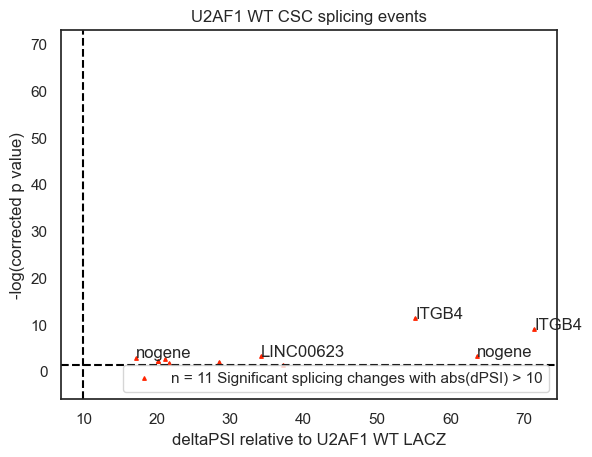

In [21]:
sig2 = wtcsc_filtered[(abs(wtcsc_filtered['dpsi'])>=10)
                              &(wtcsc_filtered['neglogp']> 1.30102999566)]
sig2text = wtcsc_filtered[(abs(wtcsc_filtered['dpsi'])>=10)
                                  &(wtcsc_filtered['neglogp']> 1.30102999566)]
sig2text = sig2text.sort_values(by=['neglogp'], ascending=False)
sig2text = sig2text.head(n=5)

sig2text['dpsi'] = sig2text['dpsi'].abs()

# Find index of the top |ΔPSI| gene
top_idx = sig2text['dpsi'].idxmax()

# Assign a custom name to that gene
sig2text.loc[top_idx, 'gene_name'] = 'ITGB4'

plt.scatter(x=abs(wtcsc_filtered['dpsi']),y=wtcsc_filtered['neglogp'], s=1, color='gray')
plt.scatter(x=abs(sig2['dpsi']),y=sig2['neglogp'],s=6,
            label=("n = %s Significant splicing changes with abs(dPSI) > 10" % (len(sig2))),
            color='#FF2501', marker='^')

plt.xlabel("deltaPSI relative to U2AF1 WT LACZ")
plt.ylabel("-log(corrected p value)")
# plt.axvline(-10,color="black",linestyle="--")
plt.axvline(10,color="black",linestyle="--")
plt.axhline(1.30102999566,color="black",linestyle="--")
plt.title('U2AF1 WT CSC splicing events')
plt.ylim(-6, 73)
# plt.yticks(range(0, 75, 10)) # clean tick marks every 10
# plt.ticklabel_format(style='plain')
# plt.yticks(range(-1, 15))
# plt.xticks([-60, -50, -40, -30, -20, -10, 0 , 10, 20, 30, 40, 50, 60])
# plt.ylim(0, 5) 
# plt.xlim(-100, 80)

sig2text = sig2text.dropna(subset=['dpsi', 'neglogp', 'gene_name'])
texts2 = []
for i in range(len(sig2text)):
    #if sig2text.iloc[i].delta_val < 61:
    texts1.append(plt.text(x= sig2text.iloc[i].dpsi, y=sig2text.iloc[i].neglogp, s= sig2text.iloc[i].gene_name))
    
adjust_text(texts2, arrowprops = dict(arrowstyle = '-', color = 'k'),  expand_points=(2, 2.2),force_text=(1, 1.2))

plt.legend(loc='lower right', facecolor="white")
# plt.savefig("Downloads/dpsi_volcano_wtkv12.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/dpsi_volcano_wtcsc_2.png", format='png', transparent=True)


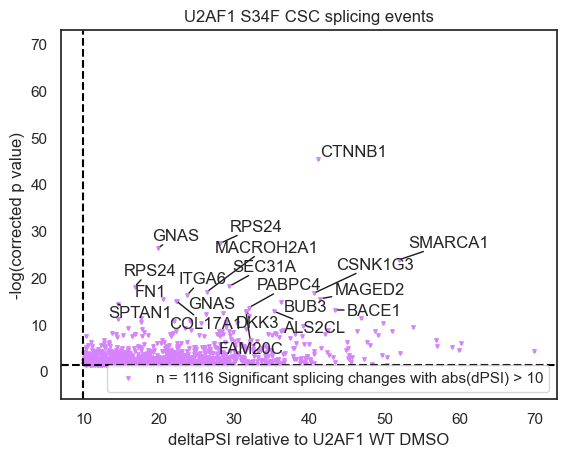

In [22]:
sig3 = s34fcsc_filtered[(abs(s34fcsc_filtered['dpsi'])>=10)&
                                (s34fcsc_filtered['neglogp']> 1.30102999566)]
sig3text = s34fcsc_filtered[(abs(s34fcsc_filtered['dpsi'])>=10)&
                                    (s34fcsc_filtered['neglogp']> 1.30102999566)]
sig3text = sig3text.replace([np.inf, -np.inf], np.nan)
sig3text = sig3text.dropna(subset=['neglogp', 'dpsi'])
sig3text = sig3text.sort_values(by=['neglogp'], ascending=False)
sig3text = sig3text.head(n=20)

#u2af1 s34f kras g12v vs u2af1 wt lacz
#plot volcano plot with lines marking deltapsi 10 and sig p value

plt.scatter(x=abs(s34fcsc_filtered['dpsi']),y=s34fcsc_filtered['neglogp'], s=1, color='gray')
plt.scatter(x=abs(sig3['dpsi']),y=sig3['neglogp'],s=6,
            label=("n = %s Significant splicing changes with abs(dPSI) > 10" % (len(sig3))),
            color='#D783FF', marker="v")

plt.xlabel("deltaPSI relative to U2AF1 WT DMSO")
plt.ylabel("-log(corrected p value)")
plt.axvline(10,color="black",linestyle="--")
plt.axhline(1.30102999566,color="black",linestyle="--")
plt.title('U2AF1 S34F CSC splicing events')
# plt.yticks(range(-1, 15))
# plt.xticks([-60, -50, -40, -30, -20, -10, 0 , 10, 20, 30, 40, 50, 60])
plt.ylim(-6, 73) 
# plt.xlim(-100, 80)


texts1 = []
for i in range(len(sig3text)):
    #if sig2text.iloc[i].delta_val < 61:
    texts1.append(plt.text(x= abs(sig3text.iloc[i].dpsi), y=sig3text.iloc[i].neglogp, s= sig3text.iloc[i].gene_name))


adjust_text(texts1, arrowprops = dict(arrowstyle = '-', color = 'k'))

plt.legend(loc='lower right', facecolor="white")

# plt.savefig("Downloads/dpsi_volcano_s34fkv12.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/dpsi__volcano_s34fcsc_2.png", format='png')


In [18]:
sig1_sorted = sig1.sort_values(by='corrected_pval', ascending=True)
sig1_sorted = sig1_sorted[sig1_sorted['corrected_pval'] <= 0.25]
# selected_rows_condition = sig3[sig3['GeneName'] == 'S100A6']
sig1_sorted.head(20)
# selected_rows_condition

,#Contains_Novel_or_Only_Known(Annotated)_Junctions,as_event_type,gene_name,exclusion_junctions,inclusion_junctions,exclusion_exons,inclusion_exons,intron-exon_junctions,neighboring_constitutive_exons,delta_val,corrected_pval,GeneName,neglogp
20745,K,jcn_only_AA,ENSG00000115414.20,chr2:215372376-215373321;chr2:215372016-215373321,chr2:215372301-215373321,NaN,chr2:215372016-215372300;chr2:215372301-215372375,chr2:215372015-215372016;chr2:215372300-215372301,NaN,10.96,0.000011,FN1,4.958607
23406,N,jcn_only_AA,ENSG00000168036.18,chr3:41239355-41239786;chr3:41239355-41239659;chr3:41239355-41239821;chr3:41239355-41239637;chr3:41239355-41239640;chr3:41239355-41244926,chr3:41239355-41239818,NaN,chr3:41239638-41239640;chr3:41239641-41239659;chr3:41239660-41239786;chr3:41239787-41239818;chr3:41239819-41239821;chr3:41239822-41244926,chr3:41239640-41239641;chr3:41239659-41239660;chr3:41239786-41239787;chr3:41239818-41239819;chr3:41239821-41239822;chr3:41244926-41244927,NaN,-39.98,0.001382,CTNNB1,2.859492
19071,N,alternative_donor,ENSG00000137818.12,chr15:69454349-69455169;chr15:69453716-69455169;chr15:69453750-69455169;chr15:69453721-69455169;chr15:69453722-69455169;chr15:69454203-69455169;chr15:69453662-69455169;chr15:69453727-69455169,chr15:69453021-69455169,NaN,chr15:69453021-69453661;chr15:69453662-69453715;chr15:69453716-69453720;chr15:69453721-69453721;chr15:69453722-69453726;chr15:69453727-69453749;chr15:69453750-69454202;chr15:69454203-69454348,chr15:69453020-69453021;chr15:69453661-69453662;chr15:69453715-69453716;chr15:69453720-69453721;chr15:69453721-69453722;chr15:69453726-69453727;chr15:69453749-69453750;chr15:69454202-69454203,NaN,10.54,0.002989,RPLP1,2.524474
15413,K,coord_cassette,ENSG00000126261.13,chr19:34428571-34431860,chr19:34428571-34430092;chr19:34430187-34430575;chr19:34430660-34431860,NaN,chr19:34430093-34430186;chr19:34430576-34430659,NaN,NaN,-48.51,0.003219,UBA2,2.492279
1221,K,alternative_last_exon,ENSG00000104231.11,"chr8:81717681-81718181,chr8:81717274-81718181;chr8:81715115-81718181",chr8:81717289-81718181,chr8:81714804-81715114,chr8:81717249-81717288,NaN,NaN,41.69,0.004263,ZFAND1,2.370285
2980,N,alternative_last_exon,ENSG00000113648.16,chr5:135335142-135360496;chr5:135359943-135360496;chr5:135346058-135360496;chr5:135359629-135360496;chr5:135353046-135360496,chr5:135350914-135360496,chr5:135333900-135335141;chr5:135359722-135359942;chr5:135345690-135346057;chr5:135359397-135359628;chr5:135352946-135353045,chr5:135350814-135350913,NaN,NaN,-21.79,0.004263,MACROH2A1,2.370285
15259,K,coord_cassette,ENSG00000205726.15,chr21:33819324-33829623,chr21:33819324-33823486;chr21:33823654-33826817;chr21:33826864-33829623,NaN,chr21:33823487-33823653;chr21:33826818-33826863,NaN,NaN,36.40,0.004638,ITSN1,2.333669
33620,K,alternative_first_exon,ENSG00000090621.14,"chr1:39563742-39563832;chr1:39563742-39564470,chr1:39563742-39564422",chr1:39563742-39563835,chr1:39564471-39564542,chr1:39563836-39564124,NaN,NaN,-32.85,0.005038,PABPC4,2.297742
33767,K,alternative_first_exon,ENSG00000161249.21,chr19:35505766-35509910;chr19:35505766-35510183,chr19:35505766-35505938,chr19:35509911-35509961;chr19:35510184-35510510,chr19:35505939-35508557,NaN,NaN,-29.32,0.005038,DMKN,2.297742
33344,K,alternative_first_exon,ENSG00000100242.15,chr22:38752666-38755762,chr22:38752666-38754641,chr22:38755763-38756000,chr22:38754642-38754993,NaN,NaN,28.44,0.005038,SUN2,2.297742


In [6]:
#sort by deltaPSI, then keep the first entry (highest value absdeltaPSI)

#filter data frames by padj < 0.25
s34fdmso_padj025 = s34fdmso_contrast_table
wtcsc_padj025 = wtcsc_contrast_table
s34fcsc_padj025 = s34fcsc_contrast_table

#take absolute value of dPSI
dflist = [s34fdmso_padj025, wtcsc_padj025, s34fcsc_padj025]
for df in dflist:
    df['abs(dPSI)'] = abs(df['dpsi'])

#for duplciates, keep only highest deltapsi entry
#first sort by descending abspsi

s34fdmso_padj025 = s34fdmso_padj025.sort_values(['abs(dPSI)'], ascending=False)
wtcsc_padj025 = wtcsc_padj025.sort_values(['abs(dPSI)'], ascending=False)
s34fcsc_padj025 = s34fcsc_padj025.sort_values(['abs(dPSI)'], ascending=False)

wtcsc_unique = wtcsc_padj025[wtcsc_padj025['gene_name'] != 'nogene']
s34fdmso_unique = s34fdmso_padj025[s34fdmso_padj025['gene_name'] != 'nogene']
s34fcsc_unique = s34fcsc_padj025[s34fcsc_padj025['gene_name'] != 'nogene']

# s34fdmso_unique = s34fdmso_padj025.drop(s34fdmso_padj025[s34fdmso_padj025['gene_name'] == 'nogene'])
# wtcsc_unique = wtcsc_padj025.drop(wtcsc_padj025[wtcsc_padj025['gene_name'] == 'nogene'])
# s34fcsc_unique = s34fcsc_padj025.drop(s34fdmso_padj025[s34fdmso_padj025['gene_name'] == 'nogene')
wtcsc_unique 

# LDHA	0.640569	59.02

,inclusion_exclusion,contains_novel_or_only_known_junctions,as_event_type,gene_name,gene_coordinates,strand,W1D2.S24_wtdmso_b1,W1D3.S32_wtdmso_b1,W2D2.S22_wtdmso_b1,W2D3.S30_wtdmso_b1,W1C2.S25_wtcsc_b1,W1C3.S33_wtcsc_b1,W2C2.S23_wtcsc_b1,lr,padj,dpsi,abs(dPSI)
0,inclusion,N,alternative_donor,ITGB4,chr17:75743751-75748954,+,0.115,0.115,0.115,0.115,0.667,0.667,0.667,67.78,3.850000e-12,55.2,55.2
10,inclusion,N,alternative_donor,IRF3,chr19:49663259-49665630,-,0.137,0.137,0.137,0.137,0.509,0.509,0.509,17.84,4.580000e-02,37.2,37.2
2,inclusion,N,alternative_donor,LINC00623,chr1:120912325-120952438,+,0.043,0.043,0.043,0.043,0.385,0.385,0.385,28.72,5.840000e-04,34.2,34.2
8,inclusion,N,alternative_donor,SQSTM1,chr5:179836666-179837716,+,0.526,0.526,0.526,0.526,0.811,0.811,0.811,21.32,9.050000e-03,28.5,28.5
9,inclusion,K,cassette,MACF1,chr1:39465095-39465112,+,0.510,0.510,0.510,0.510,0.293,0.293,0.293,20.20,1.460000e-02,-21.7,21.7
5,inclusion,N,cassette,MYO18A,chr17:29085604-29085648,-,0.675,0.675,0.675,0.675,0.464,0.464,0.464,24.29,2.900000e-03,-21.1,21.1
6,inclusion,N,alternative_donor,MIR205HG,chr1:209429089-209429180,+,0.714,0.714,0.714,0.714,0.916,0.916,0.916,21.72,8.270000e-03,20.2,20.2


In [7]:
# now convert to RNK file

#first only keep gene name and delta cols
s34fdmso_RNK = s34fdmso_unique.loc[:, s34fdmso_unique.columns.isin(['gene_name', 'as_event_type', 'abs(dPSI)'])]
wtcsc_RNK = wtcsc_unique.loc[:, wtcsc_unique.columns.isin(['gene_name',  'as_event_type','abs(dPSI)'])]
s34fcsc_RNK = s34fcsc_unique.loc[:, s34fcsc_unique.columns.isin(['gene_name',  'as_event_type','abs(dPSI)'])]

dflist = [s34fdmso_RNK, wtcsc_RNK, s34fcsc_RNK]
for df in dflist:
# then rename gene name to #Gene and reorder columns
    df = df.rename(columns = {'gene_name':'#Gene'}, inplace = True)
    
column_order = ['#Gene',  'as_event_type','abs(dPSI)']

s34fdmso_reorder = s34fdmso_RNK .reindex(column_order, axis = 1)
wtcsc_reorder = wtcsc_RNK.reindex(column_order, axis = 1)
s34fcsc_reorder = s34fcsc_RNK.reindex(column_order, axis = 1)

wtcsc_reorder.head(5)

# KRT6A	46.40

/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/2438158585.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df = df.rename(columns = {'gene_name':'#Gene'}, inplace = True)


,#Gene,as_event_type,abs(dPSI)
0,ITGB4,alternative_donor,55.2
10,IRF3,alternative_donor,37.2
2,LINC00623,alternative_donor,34.2
8,SQSTM1,alternative_donor,28.5
9,MACF1,cassette,21.7


/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/1859343426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/1859343426.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/1859343426.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

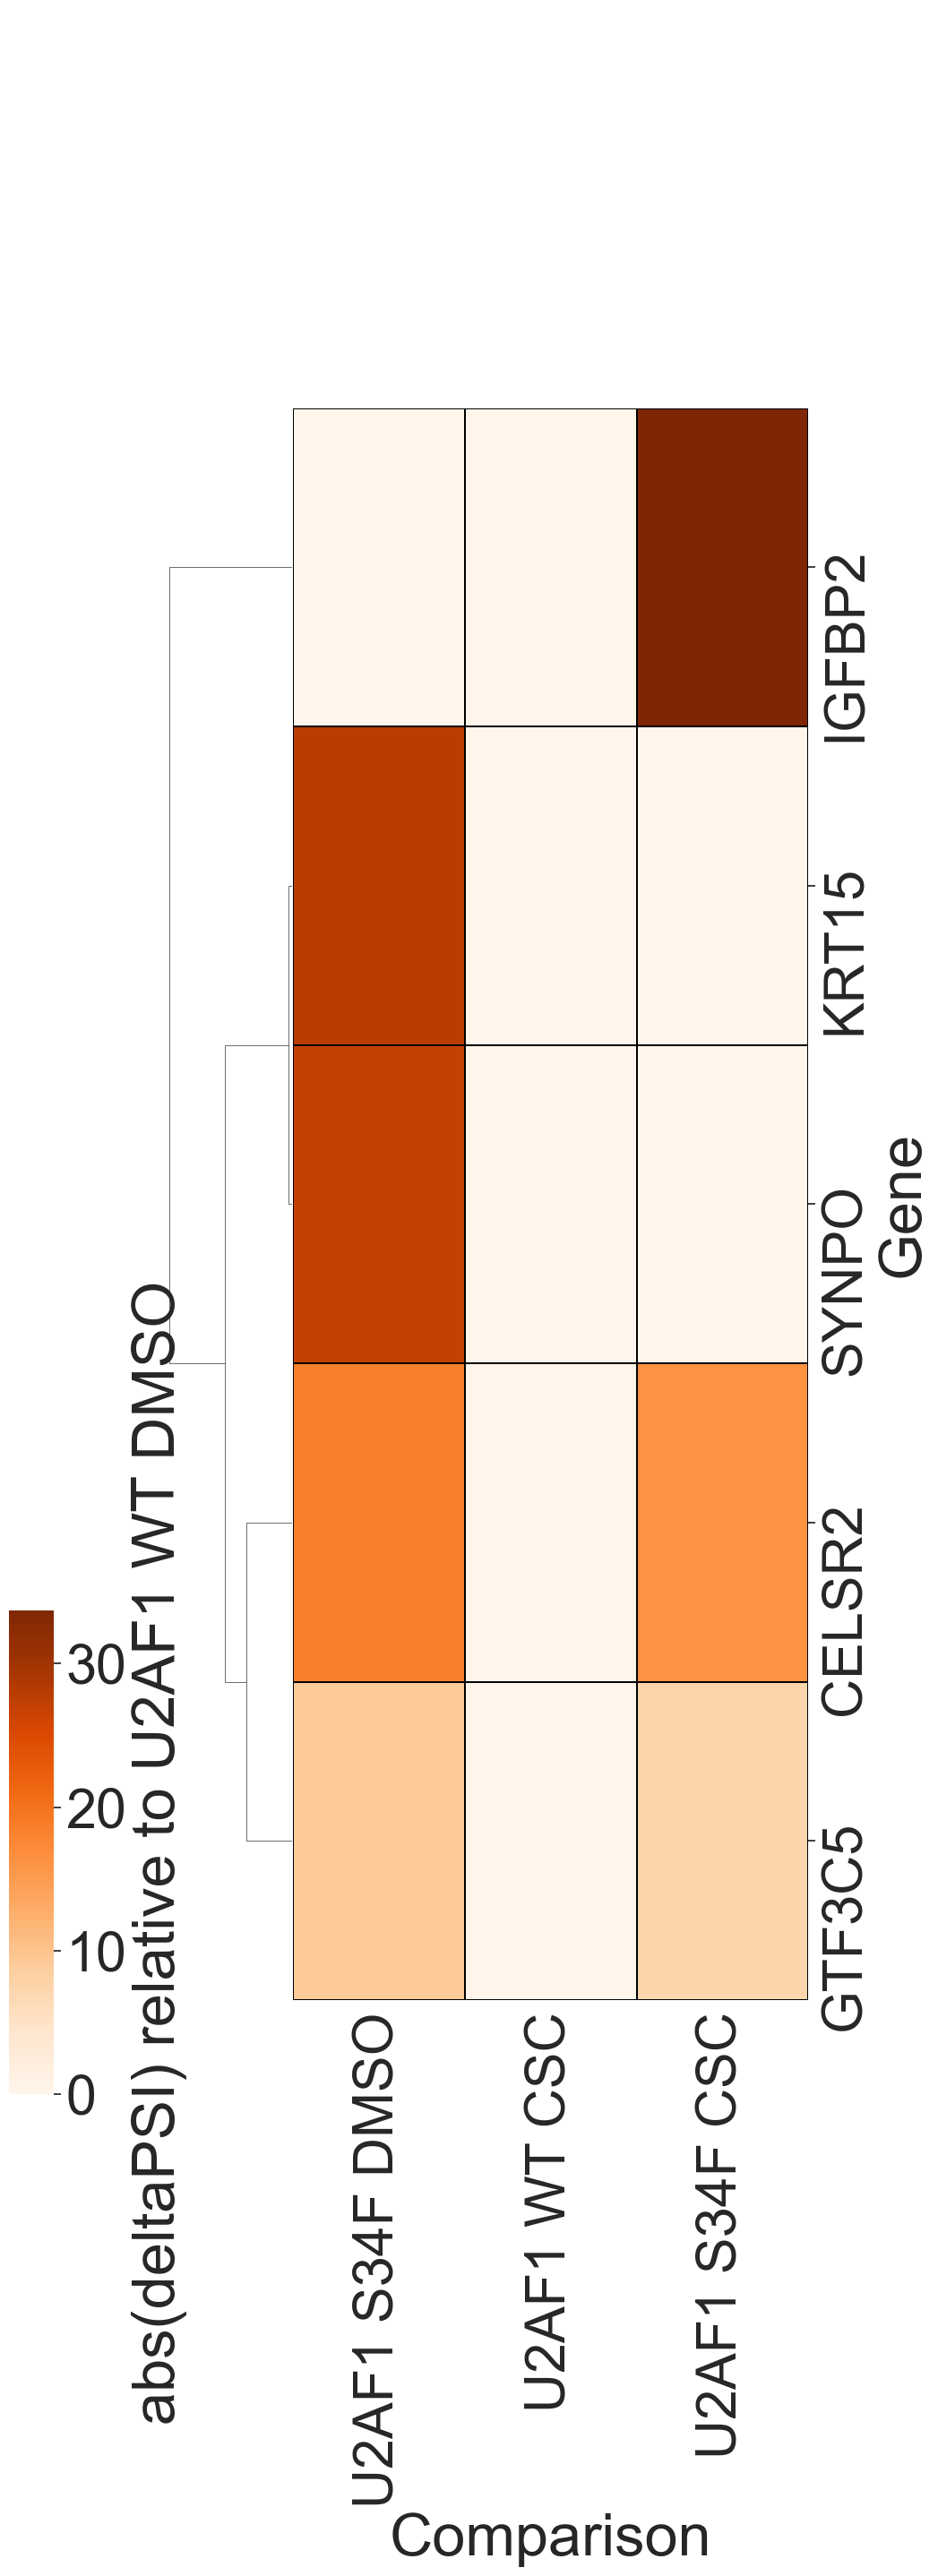

In [6]:
KRASDNstr = 'ABCB11,ABCG4,ACTC1,COQ8A,ADRA2C,AKR1B10,ALOX12B,AMBN,ARHGDIG,ARPP21,ASB7,ATP4A,ATP6V1B1,BARD1,BMPR1B,BRDT,BTG2,C5,CACNA1F,CACNG1,CALCB,CALML5,CAMK1D,CAPN9,CCDC106,VPS50,CCNA1,CCR8,CD207,CD40LG,CD80,CDH16,CDKAL1,CELSR2,CHRNG,CHST2,CKM,CLDN16,CLDN8,CLPS,CLSTN3,CNTFR,COL2A1,COPZ2,CPA2,CPB1,CPEB3,CYP11B2,CYP39A1,DCC,DLK2,DTNB,EDAR,EDN1,EDN2,EFHD1,EGF,ENTPD7,EPHA5,ZC2HC1C,TENT5C,FGF16,FGF22,FGFR3,FGGY,FSHB,GAMT,GDNF,GP1BA,GP2,GPR19,GPR3,GPRC5C,GRID2,GTF3C5,MACROH2A2,HNF1A,HSD11B2,HTR1B,HTR1D,IDUA,IFI44L,IFNG,IGFBP2,IL12B,IL5,INSL5,IRS4,ITGB1BP2,ITIH3,KCND1,KCNE2,KCNMB1,KCNN1,KCNQ2,KLHDC8A,KLK7,KLK8,KRT1,KRT13,KRT15,KRT4,KRT5,LFNG,LGALS7,LYPD3,MAGIX,MAST3,MEFV,MFSD6,KMT2D,MSH5,MTHFR,MX1,MYH7,MYO15A,MYOT,NGB,NOS1,NPHS1,NR4A2,NR6A1,NRIP2,NTF3,NUDT11,TENM2,OXT,P2RX6,P2RY4,PRKN,PAX3,PAX4,PCDHB1,PDCD1,PDE6B,PDK2,PKP1,PLAG1,PNMT,NPY4R,PRODH,PROP1,PTGFR,PTPRJ,RGS11,RIBC2,RSAD2,RYR1,RYR2,SCGB1A1,SCN10A,SELENOP,SERPINA10,SERPINB2,SGK1,SHOX2,SIDT1,SKIL,SLC12A3,SLC16A7,SLC25A23,SLC29A3,SLC30A3,SLC38A3,SLC5A5,SLC6A14,SLC6A3,SMPX,SNCB,SNN,SOX10,SPHK2,SPRR3,SPTBN2,SSTR4,STAG3,SYNPO,TAS2R4,TCF7L1,TCL1A,TEX15,TFAP2B,TFCP2L1,TFF2,TG,TGFB2,TGM1,THNSL2,THRB,TLX1,TNNI3,TSHB,UGT2B17,UPK3B,VPREB1,WNT16,YBX2,YPEL1,ZBTB16,ZNF112'
KRASDNset = set(KRASDNstr.split(','))
KRASDNlist = KRASDNstr.split(',')

sns.set(font_scale=4)

#combine dataframes for gene level heatmap
dflist = [s34fdmso_RNK, wtcsc_RNK, s34fcsc_RNK]
for df in dflist:
    df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)

s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
wtcsc_RNK['Comparison'] = 'U2AF1 WT CSC'
s34fcsc_RNK['Comparison'] = 'U2AF1 S34F CSC'

#concat dataframes
s34fdmso_wtcsc = pd.concat([s34fdmso_RNK, wtcsc_RNK], ignore_index=True)
s34fdmso_wtcsc_s34fcsc = pd.concat([s34fcsc_RNK, s34fdmso_wtcsc], ignore_index=True)

krasDownPSI_df = s34fdmso_wtcsc_s34fcsc[s34fdmso_wtcsc_s34fcsc['Gene'].isin(KRASDNlist)]

# #pivot dataframes for heatmap
heatmap_df = pd.pivot_table(krasDownPSI_df, values='abs(dPSI)', index='Gene', columns='Comparison')

# reorder columns for plotting
column_order = ['U2AF1 S34F DMSO', 'U2AF1 WT CSC', 'U2AF1 S34F CSC']
heatmap_df = heatmap_df.reindex(column_order, axis=1)

heatmap_df = heatmap_df.fillna(0)

cg = sns.clustermap(heatmap_df, figsize=(10, 30), xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01, 
                    cmap="Oranges", 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'abs(deltaPSI) relative to U2AF1 WT DMSO'})
# cg.savefig("Downloads/krasdn_dpsi_heatmap.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/Downloads/u2af1csc_krasdn_dpsi_heatmap.pdf.png", format='png', transparent=True)


/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_13501/4101065624.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_13501/4101065624.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_13501/4101065624.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

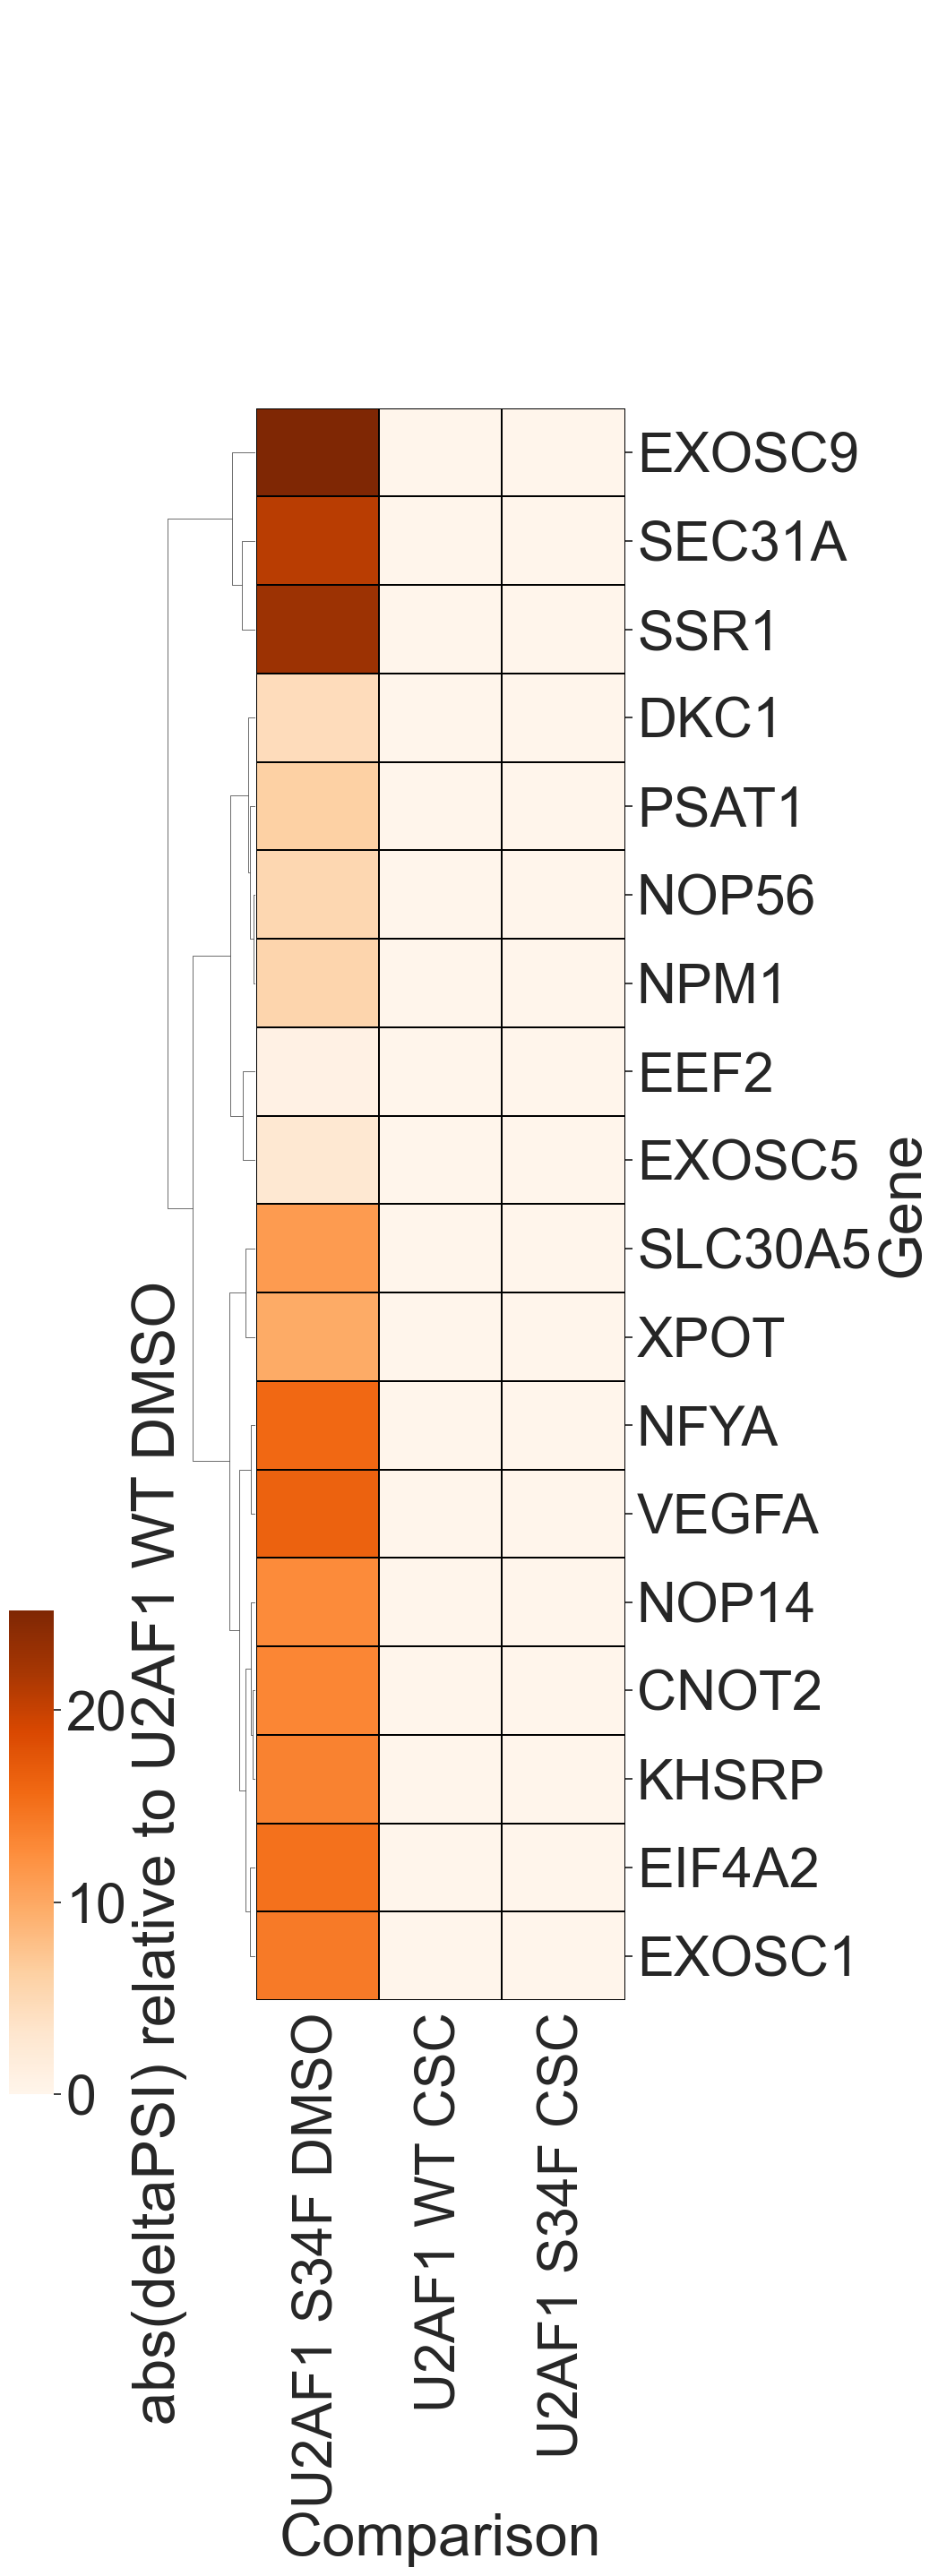

In [39]:
unfoldedproteinstr = 'ALDH18A1,ARFGAP1,ASNS,ATF3,ATF4,ATF6,ATP6V0D1,BAG3,BANF1,CALR,CCL2,CEBPB,CEBPG,CHAC1,CKS1B,CNOT2,CNOT4,CNOT6,CXXC1,DCP1A,DCP2,DCTN1,DDIT4,DDX10,DKC1,DNAJA4,DNAJB9,DNAJC3,EDC4,EDEM1,EEF2,EIF2AK3,EIF2S1,EIF4A1,EIF4A2,EIF4A3,EIF4E,EIF4EBP1,EIF4G1,ERN1,ERO1A,EXOC2,EXOSC1,EXOSC10,EXOSC2,EXOSC4,EXOSC5,EXOSC9,FKBP14,FUS,GEMIN4,GOSR2,H2AX,HERPUD1,HSP90B1,HSPA5,HSPA9,HYOU1,IARS1,IFIT1,IGFBP1,IMP3,KDELR3,KHSRP,KIF5B,LSM1,LSM4,MTHFD2,NFYA,NFYB,NHP2,NOLC1,NOP14,NOP56,NPM1,NABP1,PAIP1,PARN,PDIA5,PDIA6,POP4,PREB,PSAT1,RPS14,RRP9,SDAD1,SEC11A,SEC31A,SERP1,SHC1,MTREX,SLC1A4,SLC30A5,SLC7A5,SPCS1,SPCS3,SRPRA,SRPRB,SSR1,STC2,TARS1,TATDN2,TSPYL2,SKIC3,TUBB2A,VEGFA,WFS1,WIPI1,XBP1,XPOT,YIF1A,YWHAZ,ZBTB17'

unfoldedproteinset = set(unfoldedproteinstr.split(','))
unfoldedproteinlist = unfoldedproteinstr.split(',')

sns.set(font_scale=4)

#combine dataframes for gene level heatmap
dflist = [s34fdmso_RNK, wtcsc_RNK, s34fcsc_RNK]
for df in dflist:
    df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)

s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
wtcsc_RNK['Comparison'] = 'U2AF1 WT CSC'
s34fcsc_RNK['Comparison'] = 'U2AF1 S34F DMSO'

#concat dataframes
s34fdmso_wtcsc = pd.concat([s34fdmso_RNK, wtcsc_RNK], ignore_index=True)
s34fdmso_wtcsc_s34fcsc = pd.concat([s34fcsc_RNK, s34fdmso_wtcsc], ignore_index=True)

unfoldedPSI_df = s34fdmso_wtcsc_s34fcsc[s34fdmso_wtcsc_s34fcsc['Gene'].isin(unfoldedproteinlist)]

# #pivot dataframes for heatmap
heatmap_df = pd.pivot_table(unfoldedPSI_df, values='abs(dPSI)', index='Gene', columns='Comparison')

# reorder columns for plotting
column_order = ['U2AF1 S34F DMSO', 'U2AF1 WT CSC', 'U2AF1 S34F CSC']
heatmap_df = heatmap_df.reindex(column_order, axis=1)

heatmap_df = heatmap_df.fillna(0)

cg = sns.clustermap(heatmap_df, figsize=(10, 30), xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01, 
                    cmap="Oranges", 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'abs(deltaPSI) relative to U2AF1 WT DMSO'})
# cg.savefig("Downloads/krasdn_dpsi_heatmap.pdf", format='pdf', transparent=True
plt.savefig("/Users/selammehreteab/Downloads/u2af1csc_unfoldedprot_dpsi_heatmap.pdf.png", format='png', transparent=True)


In [9]:
#clean up SG list to only get gene names

#Stress granule protein gene list
sgproteindf = pd.read_csv('/Users/selammehreteab/Downloads/Protein_sgs.GMX', sep='\t')

sg1 = sgproteindf['SG_pr Markmiller_4'].tolist()
sg2 = sgproteindf['SG_pr Jain_1'].tolist()
sg3 = sgproteindf['SG_pr Jain_2'].tolist()
sg4 = sgproteindf['SG_pr Khong'].tolist()
sg5 = sgproteindf['SG_pr Markmiller_1'].tolist()
sg6 = sgproteindf['SG_pr Markmiller_2'].tolist()
sg7 = sgproteindf['SG_pr Markmiller_3'].tolist()
sg8 = sgproteindf['SG_pr Markmiller_4'].tolist()
sg9 = sgproteindf['SG_pr MarmorKollet_1'].tolist()
sg10 = sgproteindf['SG_pr MarmorKollet_2'].tolist()
sg11 = sgproteindf['SG_pr Youn'].tolist()


proteinSGscombined = sg1 + sg2 + sg3 + sg4 + sg5 + sg6 + sg7 + sg8 + sg9 + sg10 + sg11
    
proteinSGscombined = [i for i in proteinSGscombined if i != 'na']
proteinSGscombined = [i for i in proteinSGscombined if str(i) != 'nan']

proteinSGset = set(proteinSGscombined)

In [10]:
u2af1bind = pd.read_csv('/Users/selammehreteab/Downloads/Supplementary_Table_3 - Sheet1.csv')

u2af1_bind_list = u2af1bind['transcript']
u2af1_bind_list

0           SEPT2
1            IPO7
2            NPM1
3           SRP72
4           RAB4A
          ...    
1112         ATN1
1113       MALAT1
1114         AGO2
1115    HNRNPA1L2
1116       HNRNPK
Name: transcript, Length: 1117, dtype: object

/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/1767690087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/1767690087.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/1767690087.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

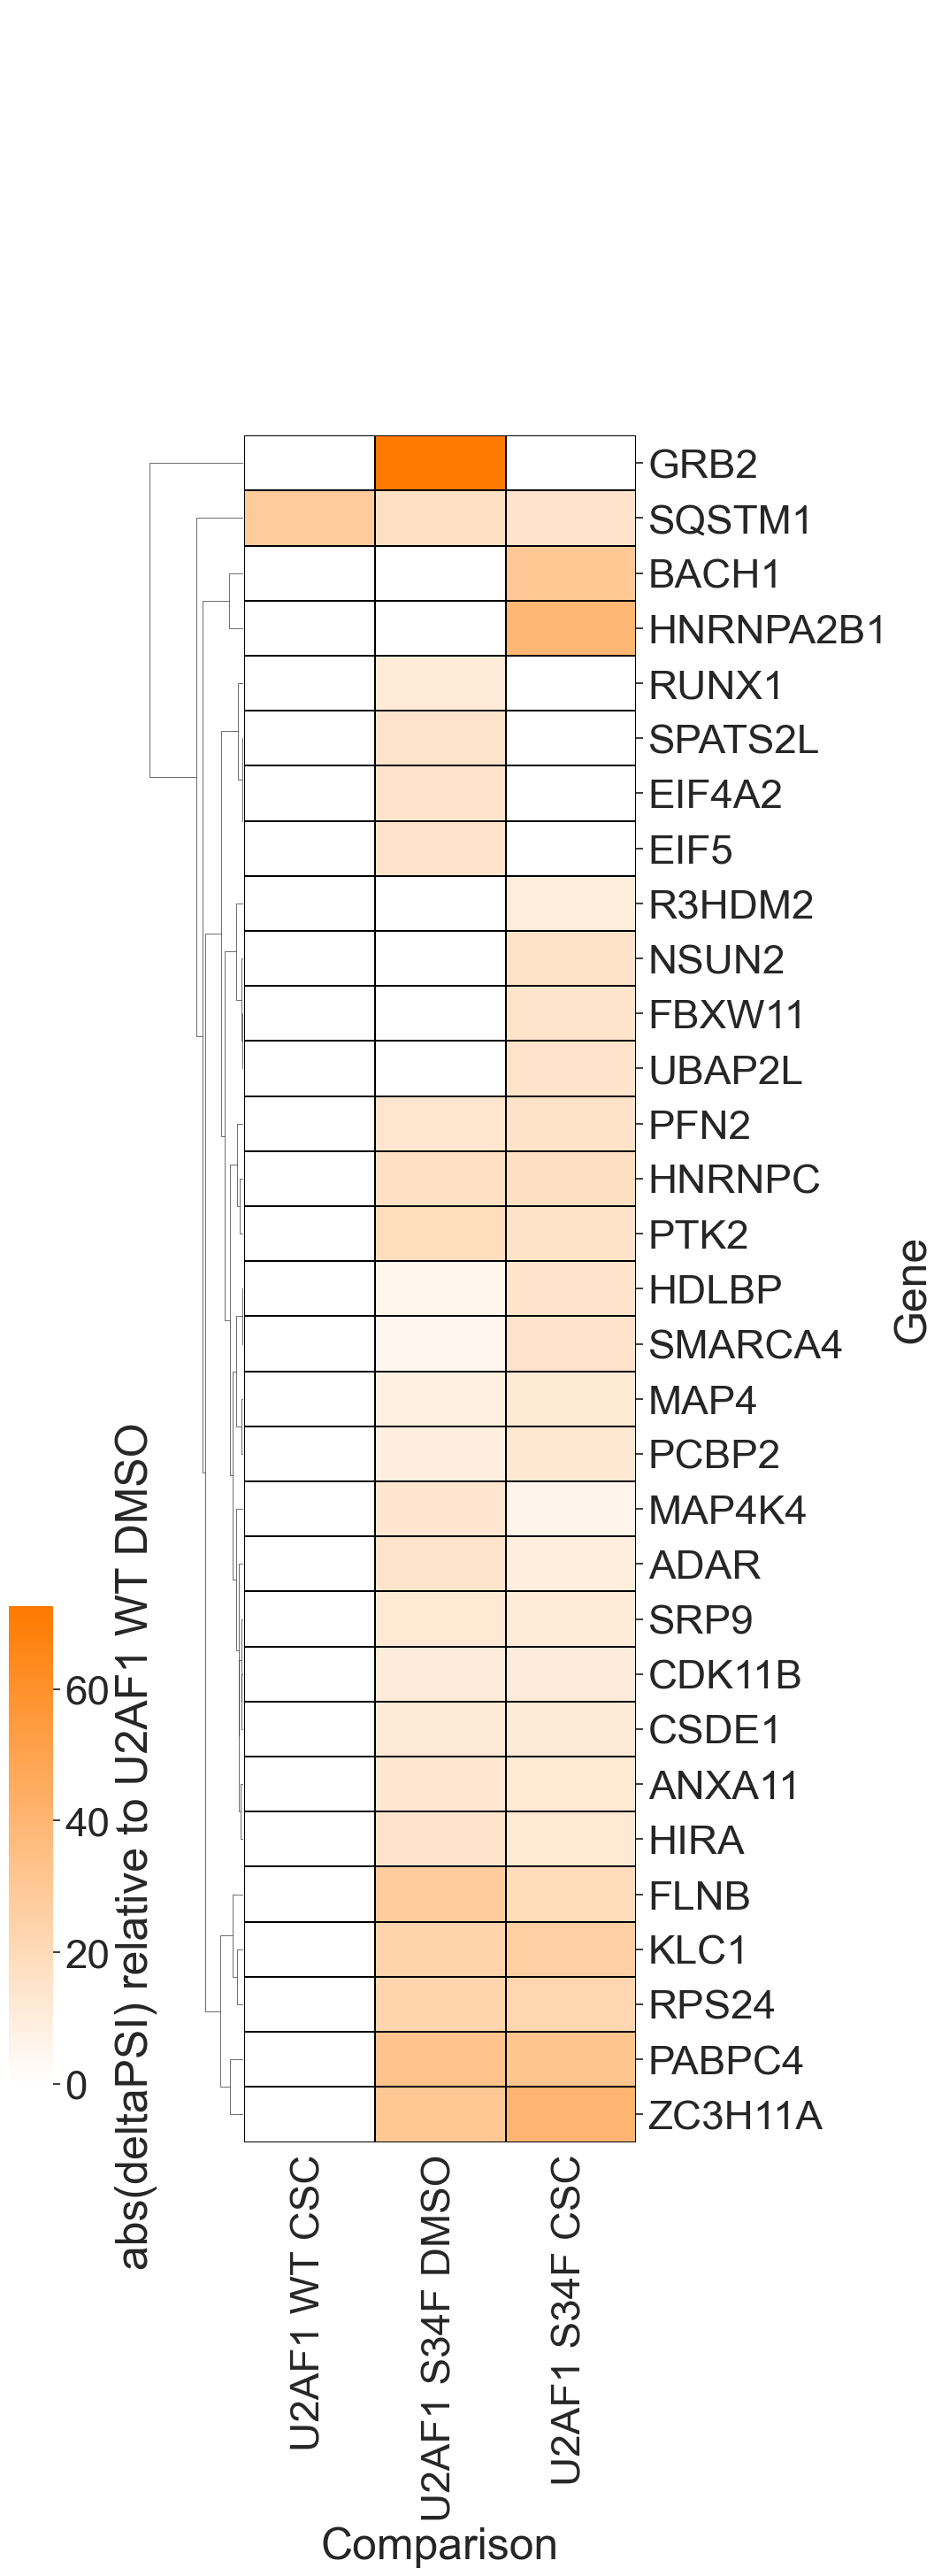

In [11]:
sns.set(font_scale=3)


dflist = [s34fdmso_RNK, wtcsc_RNK, s34fcsc_RNK]

for df in dflist:
    df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)

s34fdmso_RNK = s34fdmso_RNK.loc[s34fdmso_RNK['Gene'].isin(u2af1_bind_list)]
s34fcsc_RNK = s34fcsc_RNK.loc[s34fcsc_RNK['Gene'].isin(u2af1_bind_list)]
wtcsc_RNK = wtcsc_RNK.loc[wtcsc_RNK['Gene'].isin(u2af1_bind_list)]

    
s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
wtcsc_RNK['Comparison'] = 'U2AF1 WT CSC'
s34fcsc_RNK['Comparison'] = 'U2AF1 S34F CSC'

#concat dataframes
s34fdmso_wtcsc = pd.concat([s34fdmso_RNK, wtcsc_RNK], ignore_index=True)
s34fdmso_wtcsc_s34fcsc = pd.concat([s34fcsc_RNK, s34fdmso_wtcsc], ignore_index=True)
# s34flacz_wtkv12_s34fkv12

#filter for cols that correspond to gene in sg protein 
sg_df = s34fdmso_wtcsc_s34fcsc[s34fdmso_wtcsc_s34fcsc['Gene'].isin(proteinSGset)]

#pivot dataframes for heatmap
heatmap_df = pd.pivot_table(sg_df, values='abs(dPSI)', index='Gene', columns='Comparison')
# heatmap_df = pd.pivot_table(sg_df, values='abs(dPSI)', index='Gene_Event', columns='Comparison')
heatmap_df = heatmap_df[
    (heatmap_df.abs() >= 10).any(axis=1)
]

# column_order = [ 'U2AF1 WT CSC', 'U2AF1 S34F DMSO','U2AF1 S34F CSC']
# heatmap_df = heatmap_df.reindex(column_order, axis=1)

#reorder columns for plotting
column_order = ['U2AF1 WT CSC','U2AF1 S34F DMSO', 'U2AF1 S34F CSC']
heatmap_df = heatmap_df.reindex(column_order, axis=1)

#check if there's anything with value = 0
# heatmap_df[heatmap_df.isin([0]).any(axis=1)]

white_orange = LinearSegmentedColormap.from_list(
    "gray_orange",
    ["#FFFFFF", "#FF7A00"]   
)
heatmap_df = heatmap_df.fillna(0)


cg = sns.clustermap(heatmap_df, figsize=(10, 30), xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01, 
                    cmap=white_orange, 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'abs(deltaPSI) relative to U2AF1 WT DMSO'})
# cg.savefig("Downloads/sg_dpsi_heatmap.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/Downloads/u2af1csc_sg_dpsi_heatmap.pdf", format='pdf', transparent=True,bbox_inches='tight' )


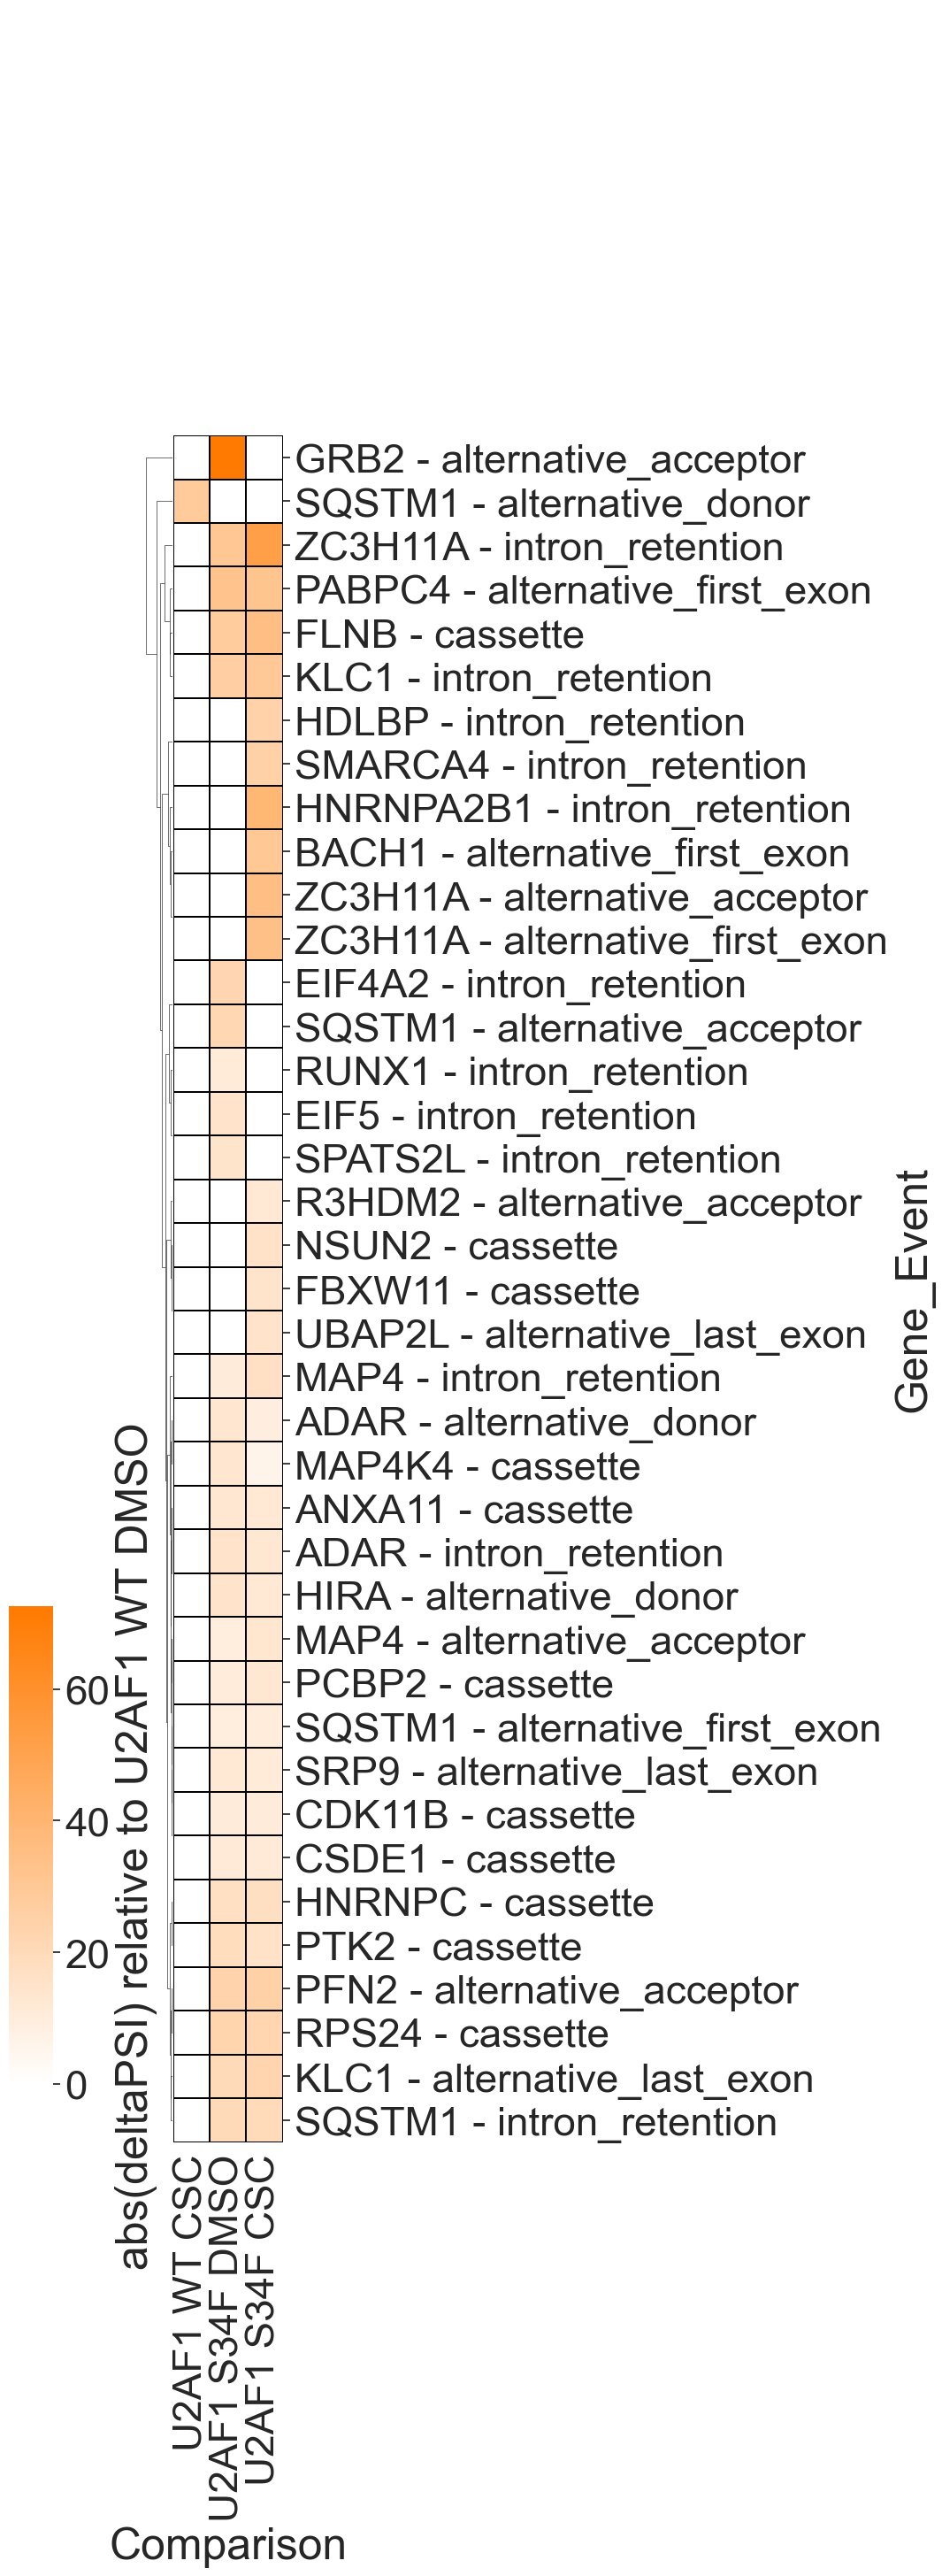

In [15]:
from matplotlib.colors import LinearSegmentedColormap
sns.set(font_scale=3)


dflist = [s34fdmso_RNK, wtcsc_RNK, s34fcsc_RNK]

for df in dflist:
    df = df.rename(columns = {'#Gene':'Gene'}, inplace = True)

s34fdmso_RNK = s34fdmso_RNK.loc[s34fdmso_RNK['Gene'].isin(u2af1_bind_list)]
s34fcsc_RNK = s34fcsc_RNK.loc[s34fcsc_RNK['Gene'].isin(u2af1_bind_list)]
wtcsc_RNK = wtcsc_RNK.loc[wtcsc_RNK['Gene'].isin(u2af1_bind_list)]

    
s34fdmso_RNK['Comparison'] = 'U2AF1 S34F DMSO'
wtcsc_RNK['Comparison'] = 'U2AF1 WT CSC'
s34fcsc_RNK['Comparison'] = 'U2AF1 S34F CSC'

#concat dataframes
s34fdmso_wtcsc = pd.concat([s34fdmso_RNK, wtcsc_RNK], ignore_index=True)
s34fdmso_wtcsc_s34fcsc = pd.concat([s34fcsc_RNK, s34fdmso_wtcsc], ignore_index=True)
s34fdmso_wtcsc_s34fcsc['Gene_Event'] = (
    s34fdmso_wtcsc_s34fcsc['Gene'] 
    + ' - ' 
    + s34fdmso_wtcsc_s34fcsc['as_event_type']
)

#filter for cols that correspond to gene in sg protein 
sg_df = s34fdmso_wtcsc_s34fcsc[s34fdmso_wtcsc_s34fcsc['Gene'].isin(proteinSGset)]

#pivot dataframes for heatmap
heatmap_df = pd.pivot_table(sg_df, values='abs(dPSI)', index='Gene_Event', columns='Comparison')
heatmap_df = heatmap_df[
    (heatmap_df.abs() >= 10).any(axis=1)
]

#reorder columns for plotting
column_order = [ 'U2AF1 WT CSC', 'U2AF1 S34F DMSO','U2AF1 S34F CSC']
heatmap_df = heatmap_df.reindex(column_order, axis=1)

#check if there's anything with value = 0
# heatmap_df[heatmap_df.isin([0]).any(axis=1)]
white_orange = LinearSegmentedColormap.from_list(
    "gray_orange",
    ["#FFFFFF", "#FF7A00"]   
)
heatmap_df = heatmap_df.fillna(0)

cg = sns.clustermap(heatmap_df, figsize=(10, 30), xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01, 
                    cmap=white_orange, 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'abs(deltaPSI) relative to U2AF1 WT DMSO'})
plt.savefig("/Users/selammehreteab/Downloads/v2_u2af1csc_sg_dpsi_heatmap.png", format='png', transparent=True)


/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/3060587163.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10_FDR'] = -np.log10(df['FDR'])
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/3060587163.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpsi_s34fdmso['Comparison'] = 'MT DMSO'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_49555/3060587163.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

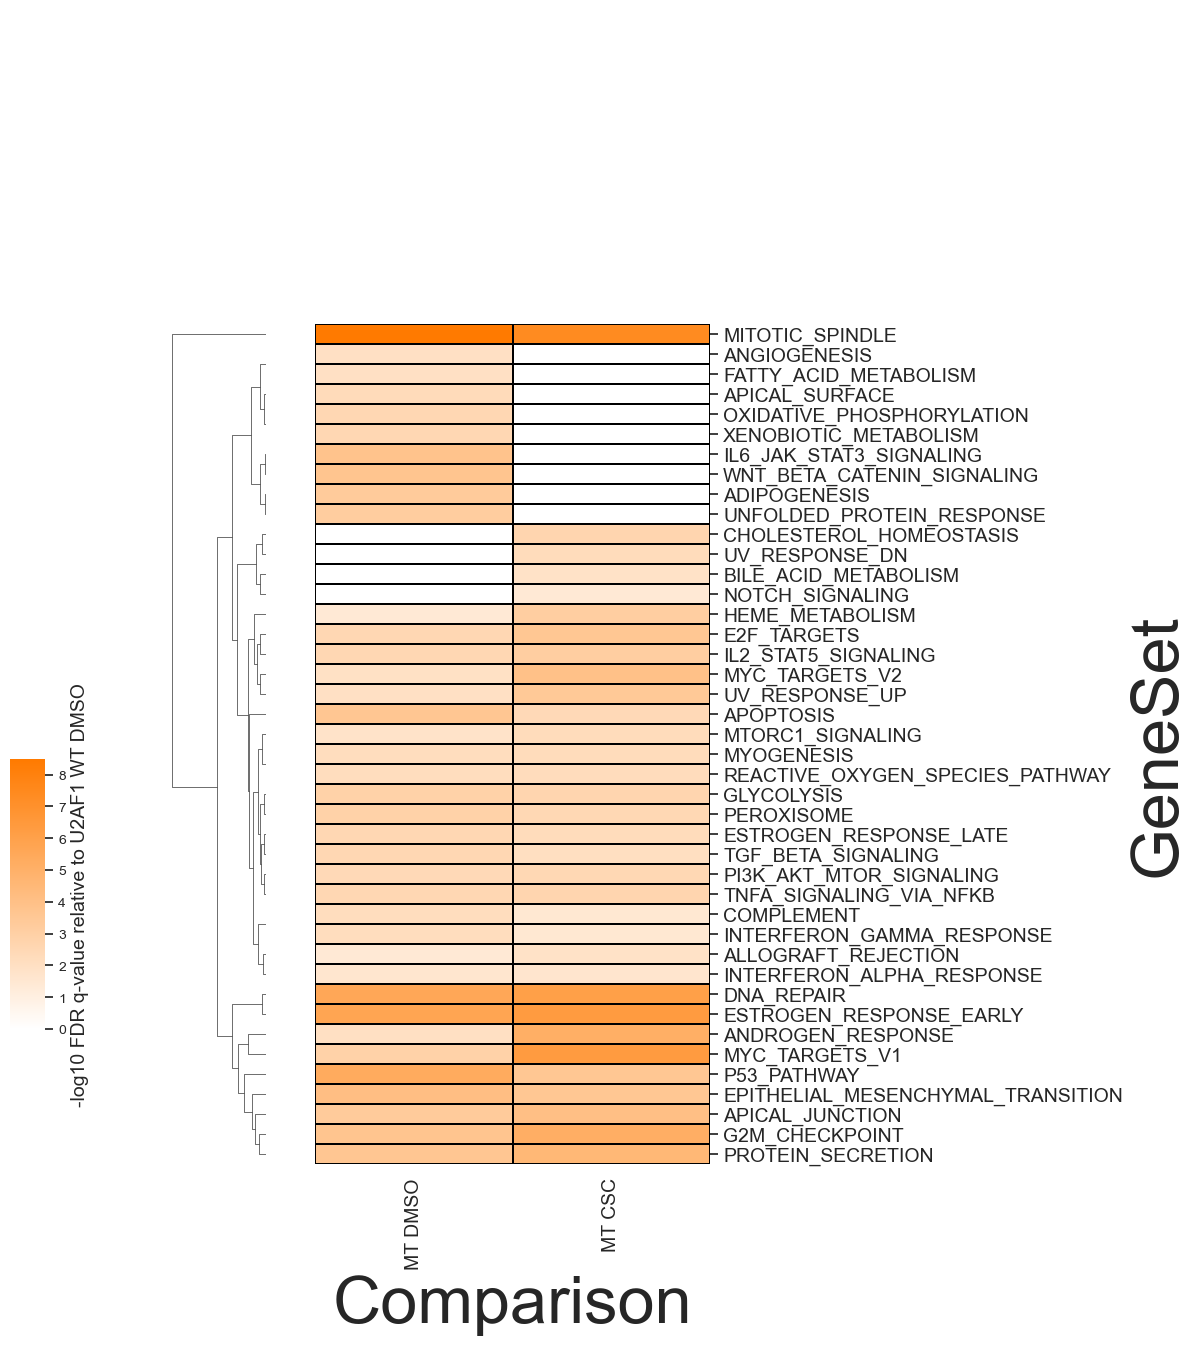

In [7]:
from matplotlib.colors import LinearSegmentedColormap
s34fcsc = pd.read_csv('/Users/selammehreteab/Downloads/v2_mtcsc_dpsi_hallmark_unrank_gsea_results.tsv', sep='\t')

s34fdmso = pd.read_csv('/Users/selammehreteab/Downloads/v2_mtdmso_dpsi_hallmark_unrank_gsea_results.tsv', sep='\t')

wtcsc = pd.read_csv('/Users/selammehreteab/Downloads/v2_wtcsc_dpsi_hallmark_unrank_gsea_results.tsv', sep='\t')



dpsi_s34fcsc = s34fcsc.loc[(s34fcsc['FDR'] <= 0.05)]

dpsi_wtcsc = wtcsc.loc[(wtcsc['FDR'] <= 0.05)]

dpsi_s34fdmso = s34fdmso.loc[(s34fdmso['FDR'] <= 0.05)]

dflist = [dpsi_s34fcsc, dpsi_wtcsc, dpsi_s34fdmso]
for df in dflist:
    df['-log10_FDR'] = -np.log10(df['FDR'])
    dpsi_s34fdmso['Comparison'] = 'MT DMSO'
    dpsi_s34fcsc['Comparison'] = 'MT CSC'
    dpsi_wtcsc['Comparison'] = 'WT CSC'
    
    
s34fdmso_wtcsc = pd.concat([dpsi_s34fdmso,dpsi_wtcsc], ignore_index = True)
s34fdmso_wtcsc_s34fcsc = pd.concat([dpsi_s34fcsc, s34fdmso_wtcsc], ignore_index = True)

heatmap_s34fwtdmsocsc = pd.pivot_table(s34fdmso_wtcsc_s34fcsc, values = '-log10_FDR', index = 'GeneSet', columns = 'Comparison')
heatmap_s34fwtdmsocsc = heatmap_s34fwtdmsocsc[
    ['MT DMSO', 'MT CSC']
]
# heatmap_s34fwtdmsocsc
heatmap_s34fwtdmsocsc = heatmap_s34fwtdmsocsc.fillna(0)
heatmap_s34fwtdmsocsc.index = heatmap_s34fwtdmsocsc.index.str.replace('HALLMARK_', '', regex=False)

white_orange = LinearSegmentedColormap.from_list(
    "gray_orange",
    ["#FFFFFF", "#FF7A00"]   
)

cg = sns.clustermap(heatmap_s34fwtdmsocsc,  figsize=(7, 15),xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01,
                    cmap=white_orange, 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'-log10 FDR q-value relative to U2AF1 WT DMSO'})

cg.ax_heatmap.tick_params(axis='both', labelsize=14)

# Make colorbar label smaller
cg.cax.tick_params(labelsize=10)
cg.cax.set_ylabel(cg.cax.get_ylabel(),fontsize=14)
# cg.savefig("Downloads/sg_dpsi_heatmap.pdf", format='pdf', transparent=True)
plt.savefig("/Users/selammehreteab/Downloads/v2_splicing_hallmark_gsea_dpsi_heatmap.pdf", format='pdf', bbox_inches='tight')

/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/794393332.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpsi_s34fdmso['Comparison'] = 'MD'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/794393332.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dpsi_s34fdmso['Comparison'] = 'MD'
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_88155/794393332.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

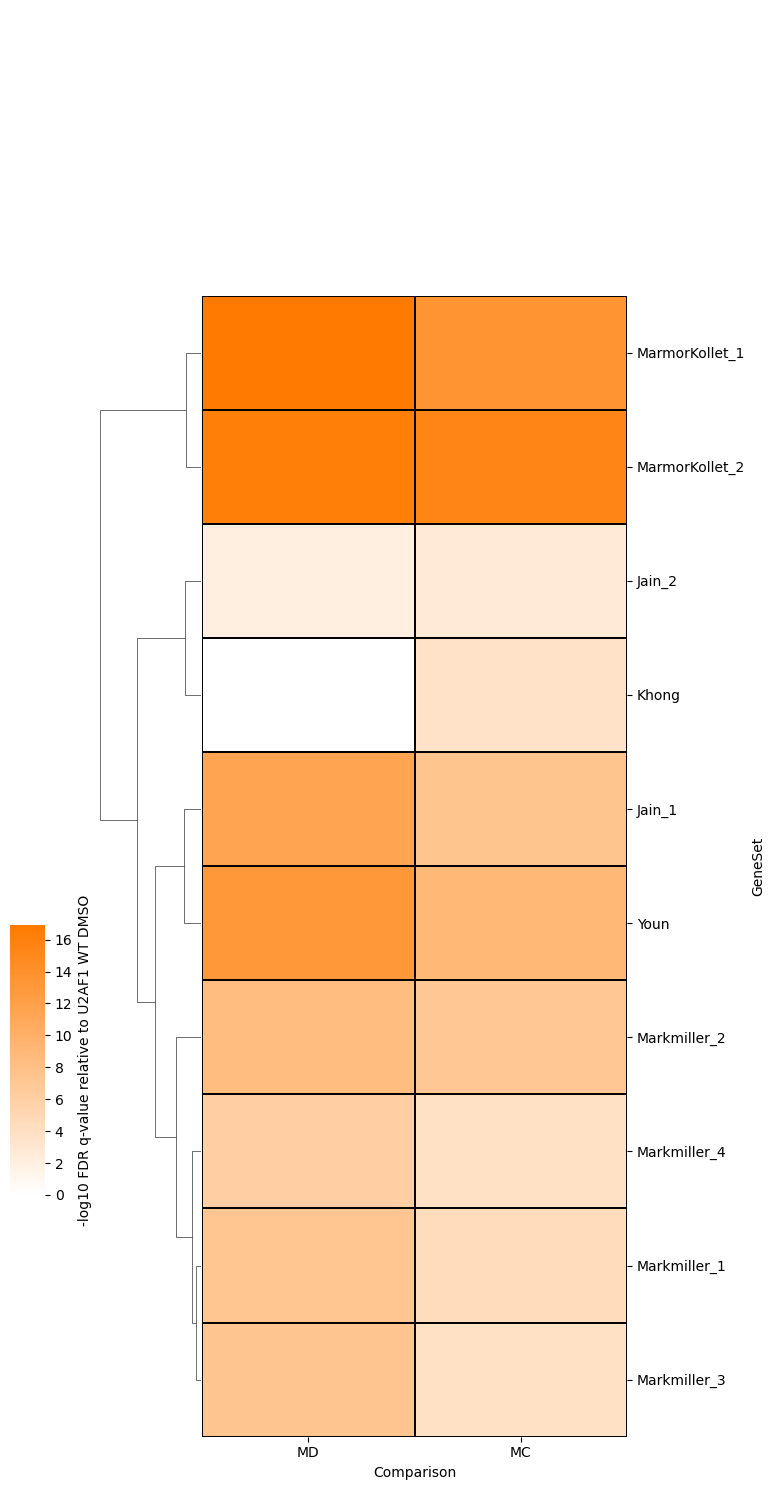

In [2]:
from matplotlib.colors import LinearSegmentedColormap
s34fcsc = pd.read_csv('/Users/selammehreteab/Downloads/s34fcsc_dpsi_sg_unrank_gsea_results.tsv', sep='\t')

s34fdmso = pd.read_csv('/Users/selammehreteab/Downloads/s34fdmso_dpsi_sg_unrank_gsea_results.tsv', sep='\t')

wtcsc = pd.read_csv('/Users/selammehreteab/Downloads/wtcsc_dpsi_sg_unrank_gsea_results.tsv', sep='\t')



dpsi_s34fcsc = s34fcsc.loc[(s34fcsc['FDR'] <= 0.05)]

dpsi_wtcsc = wtcsc.loc[(wtcsc['FDR'] <= 0.05)]

dpsi_s34fdmso = s34fdmso.loc[(s34fdmso['FDR'] <= 0.05)]

dflist = [dpsi_s34fcsc, dpsi_wtcsc, dpsi_s34fdmso]
for df in dflist:
    df['-log10_FDR'] = -np.log10(df['FDR'])
    dpsi_s34fdmso['Comparison'] = 'MD'
    dpsi_s34fcsc['Comparison'] = 'MC'
    dpsi_wtcsc['Comparison'] = 'WC'
    
    
s34fdmso_wtcsc = pd.concat([dpsi_s34fdmso,dpsi_wtcsc], ignore_index = True)
s34fdmso_wtcsc_s34fcsc = pd.concat([dpsi_s34fcsc, s34fdmso_wtcsc], ignore_index = True)

heatmap_s34fwtdmsocsc = pd.pivot_table(s34fdmso_wtcsc_s34fcsc, values = '-log10_FDR', index = 'GeneSet', columns = 'Comparison')
heatmap_s34fwtdmsocsc = heatmap_s34fwtdmsocsc[
    ['MD', 'MC']
]
# heatmap_s34fwtdmsocsc
heatmap_s34fwtdmsocsc = heatmap_s34fwtdmsocsc.fillna(0)
white_orange = LinearSegmentedColormap.from_list(
    "gray_orange",
    ["#FFFFFF", "#FF7A00"]   
)

cg = sns.clustermap(heatmap_s34fwtdmsocsc,  figsize=(7, 15),xticklabels=True, yticklabels=True, col_cluster=False, linecolor='black', 
               linewidths = 0.01,
                    cmap=white_orange, 
                    cbar_pos=(-.1, .2, 0.05, 0.18),
                    cbar_kws = {'label':'-log10 FDR q-value relative to U2AF1 WT DMSO'})

# cg.ax_heatmap.tick_params(axis='both', labelsize=14)

# # Make colorbar label smaller
# cg.cax.tick_params(labelsize=14)
# cg.cax.set_ylabel(
#     cg.cax.get_ylabel(),
#     fontsize=14
# )
cg.savefig("/Users/selammehreteab/Downloads/v2_splicing_sg_dpsi_heatmap.pdf", format='pdf', transparent=True)

In [2]:
# now
afe_juncbase_lennorm = pd.read_csv('/Users/selammehreteab/Downloads/2nd_run_afe_morpheus_input_table.tsv', sep = "\t")
# afe_juncbase_lennorm[['Novel/Known', 'event_type', 'gene_id', 'strand', 'gene_coordinates']] = afe_juncbase_lennorm['gene_id'].str.split(';', expand=True)

dflist = [afe_juncbase_lennorm]

# afe_juncbase_lennorm['gene_name'] = afe_juncbase_lennorm['gene_id']

# afe_juncbase = afe_juncbase_lennorm[afe_juncbase_lennorm['gene_coordinates'].isin(s34fdmso_contrast_table['gene_coordinates'])]

# s34fdmso_only =  set(afe_s34fdmso_contrast_table['gene_name']) - set(afe_s34fcsc_contrast_table['gene_name'])
set_cell_cycle = set(('RASAL2','TRA2B', 'PDS5B', 'TMPO', 'PML', 'TNPO2', 'BCAR1', 'SYPNO', 'CLASP1', 'ARHGEF3', 'GINS1', 'NCOR2', 'TRIM33', 'BCL2L1', 'FLT3LG', 'PLEC', 'FAS', 'FBXW7', 'SESN1'))
afe_juncbase_lennorm = afe_juncbase_lennorm[afe_juncbase_lennorm['gene_name'].isin(set_cell_cycle)]
afe_juncbase_lennorm = afe_juncbase_lennorm.fillna(0)
afe_juncbase_lennorm['WD'] = afe_juncbase_lennorm['W1D2_S24'] + afe_juncbase_lennorm['W1D3_S32'] + afe_juncbase_lennorm['W2D2_S22'] + afe_juncbase_lennorm['W2D3_S30']
afe_juncbase_lennorm['WD'] = (afe_juncbase_lennorm['WD']/4)
afe_juncbase_lennorm['WC'] = afe_juncbase_lennorm['W1C2_S25'] + afe_juncbase_lennorm['W1C3_S33'] + afe_juncbase_lennorm['W2C2_S23'] + afe_juncbase_lennorm['W2C3_S31']
afe_juncbase_lennorm['WC'] = (afe_juncbase_lennorm['WC']/4)
afe_juncbase_lennorm['MD'] = afe_juncbase_lennorm['M1D2_S28'] + afe_juncbase_lennorm['M1D3_S36'] + afe_juncbase_lennorm['M2D2_S26'] + afe_juncbase_lennorm['M2D3_S34']
afe_juncbase_lennorm['MD'] = (afe_juncbase_lennorm['MD'] /4)
afe_juncbase_lennorm['MC'] = afe_juncbase_lennorm['M1C2_S29'] + afe_juncbase_lennorm['M1C3_S37'] + afe_juncbase_lennorm['M2C2_S27'] + afe_juncbase_lennorm['M2C3_S35']
afe_juncbase_lennorm['MC'] = (afe_juncbase_lennorm['MC']/4)

afe_juncbase_lennorm = afe_juncbase_lennorm[['gene_name', 'WD', 'WC', 'MD', 'MC']]
# afe_juncbase_lennorm = afe_juncbase_lennorm.set_index('gene_name')
# afe_juncbase_lennorm[afe_juncbase_lennorm['gene_name']=='ABL1']
# afe_juncbase_lennorm.to_csv('/Users/selammehreteab/Downloads/afe_s34fdmsoonly_mrph_input.tsv', )
afe_juncbase_lennorm

,gene_name,WD,WC,MD,MC
0,FLT3LG,84.9125,88.7450,97.1150,95.8125
5,TNPO2,64.3550,58.1100,35.6750,54.8150
8,FAS,31.1825,28.3400,53.6775,25.0000
31,BCL2L1,34.9100,41.4000,54.5975,30.1625
55,TRIM33,80.8900,86.8275,58.4850,61.8175
57,GINS1,80.0375,54.1275,98.6850,93.4975
71,SESN1,53.4100,38.4225,90.5600,71.1925
72,BCAR1,81.7375,85.3125,94.0975,82.3975
105,FBXW7,16.4950,11.6900,44.8475,20.7975
106,PDS5B,50.3875,71.8725,82.8125,77.5750


In [84]:
# rows_to_drop = [1, 10, 16, 62, 111, 114, 143, 144, 211, 212, 237, 263, 270, 279, 315, 443, 467, 515]

# afe_juncbase = afe_juncbase_lennorm.drop(index=rows_to_drop)
afe_juncbase_lennorm= afe_juncbase_lennorm.set_index('gene_name')
# afe_juncbase
# afe_juncbase_lennorm.index
afe_juncbase_lennorm.to_csv('/Users/selammehreteab/Downloads/2ndjunc_afe_s34fdmsoonly_mrph_in.tsv', sep = '\t')

In [85]:
afe_juncbase_lennorm

,WD,WC,MD,MC
gene_name,,,,
FLT3LG,84.9125,88.7450,97.1150,95.8125
TNPO2,64.3550,58.1100,35.6750,54.8150
FAS,31.1825,28.3400,53.6775,25.0000
BCL2L1,34.9100,41.4000,54.5975,30.1625
TRIM33,80.8900,86.8275,58.4850,61.8175
GINS1,80.0375,54.1275,98.6850,93.4975
SESN1,53.4100,38.4225,90.5600,71.1925
BCAR1,81.7375,85.3125,94.0975,82.3975
FBXW7,16.4950,11.6900,44.8475,20.7975


In [4]:
my_columns = ['#Contains_Novel_or_Only_Known(Annotated)_Junctions','as_event_type','gene_name','chr','strand','exclusion_junctions','inclusion_junctions','exclusion_exons','inclusion_exons','intron-exon_junctions','neighboring_constitutive_exons','W1D2_S24','W1D3_S32','W2D2_S22', 'W2D3_S30','W1C2_S25','W1C3_S33','W2C2_S23','W2C3_S31','M1D2_S28','M1D3_S36','M2D2_S26','M2D3_S34','M1C2_S29','M1C3_S37','M2C2_S27','M2C3_S35']
exon1c = pd.read_csv('/Users/selammehreteab/Downloads/test_afe.txt', sep = "\t", header=None, names=my_columns)
# exon1c = exon1c[exon1c['inclusion_exons'] == 'chr20:31722444-31722548']
exon1c['WD'] = exon1c[['W1D2_S24','W1D3_S32','W2D2_S22','W2D3_S30']].median(axis=1)
exon1c['WC'] = exon1c[['W1C2_S25','W1C3_S33','W2C2_S23','W2C3_S31']].median(axis=1)
exon1c['MD'] = exon1c[['M1D2_S28','M1D3_S36','M2D2_S26','M2D3_S34']].median(axis=1)
exon1c['MC'] = exon1c[['M1C2_S29','M1C3_S37','M2C2_S27','M2C3_S35']].median(axis=1)

exon1c['WD'] = exon1c['WD']/100
exon1c['WC'] = exon1c['WC']/100
exon1c['MD'] = exon1c['MD']/100
exon1c['MC'] = exon1c['MC']/100

event_map = {
    'chr20:31722444-31722548': 'exon_1c',
    'chr20:31722618-31723098': 'exon_1a',
    'chr20:31723864-31723954': 'exon_1b'
}
exon1c['event'] = exon1c['inclusion_exons'].map(event_map)


exon1c = exon1c[['gene_name', 'inclusion_exons','WD', 'WC', 'MD', 'MC', 'event']]

# exon1c = exon1c.groupby('inclusion_exons', as_index=False).sum()
exon1c

,gene_name,inclusion_exons,WD,WC,MD,MC,event
0,ENSG00000171552.13,chr20:31723864-31723954,0.082623,0.040190,0.208499,0.104344,exon_1b
1,ENSG00000171552.13,chr20:31722444-31722548,0.041851,0.030202,0.015601,0.052421,exon_1c
2,ENSG00000171552.13,chr20:31722618-31723098,0.496333,0.568755,0.660924,0.456176,exon_1a


In [21]:
# combined_bcl2l1_exon = pd.concat([afe_bcl2l1_barplot, exon1c])
# combined_bcl2l1_exon 

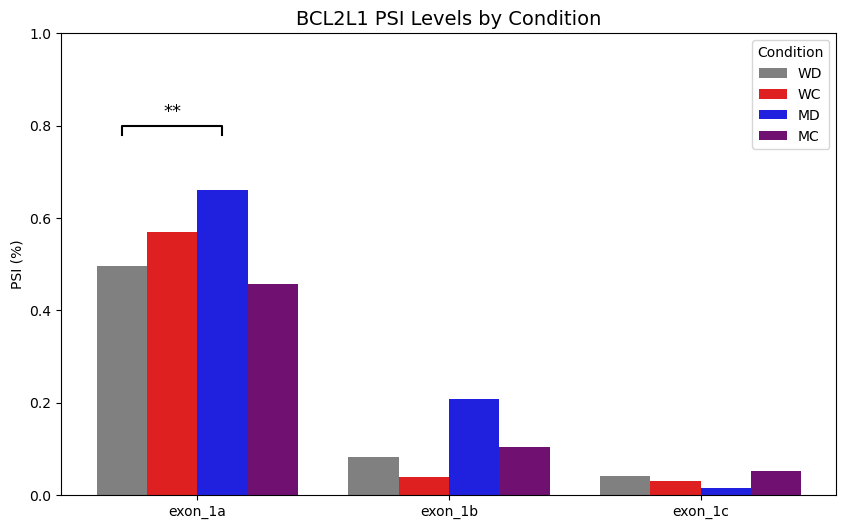

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

exon1c['event'] = ['exon_1b', 'exon_1c', 'exon_1a']

df_melted = exon1c.melt(
    id_vars=['event'], 
    value_vars=['WD', 'WC', 'MD', 'MC'],
    var_name='Condition', 
    value_name='PSI'
)


custom_palette = {
    'WD': 'gray',
    'WC': 'red',
    'MD': 'blue',
    'MC': 'purple'
}
isoform_order = ['exon_1a', 'exon_1b', 'exon_1c']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_melted, 
    x='event', 
    y='PSI', 
    hue='Condition', 
    order =isoform_order,
    palette= custom_palette,
    ax=ax
)

iso_idx = isoform_order.index('exon_1a')   # = 0
x1 = bar_positions[iso_idx][conditions.index('WD')]  # gray bar
x2 = bar_positions[iso_idx][conditions.index('MD')]  # blue bar
y = 0.8 

ax.plot([x1, x1, x2, x2], [y - 0.02, y, y, y - 0.02],
        lw=1.5, color='black', clip_on=False)
ax.text((x1 + x2) / 2, y + 0.01, '**',
        ha='center', va='bottom', fontsize=13, clip_on=False)


plt.title('BCL2L1 PSI Levels by Condition', fontsize=14)
plt.ylabel('PSI (%)')
plt.xlabel('') 
plt.ylim(0, 1)
plt.legend(title='Condition')

# plt.savefig("/Users/selammehreteab/Downloads/bcl2l1_barplot_isoforms_psi.png", format='png', transparent=True)
plt.savefig("/Users/selammehreteab/Downloads/bcl2l1_barplot_isoforms_psi.png", format='png')


In [20]:
s34fdmso_contrast_table[s34fdmso_contrast_table['gene_name'] == 'BCL2L1']

,inclusion_exclusion,contains_novel_or_only_known_junctions,as_event_type,gene_name,gene_coordinates,strand,W1D2.S24_wtdmso_b1,W1D3.S32_wtdmso_b1,W2D2.S22_wtdmso_b1,W2D3.S30_wtdmso_b1,M1D2.S28_mtdmso_b1,M1D3.S36_mtdmso_b1,M2D2.S26_mtdmso_b1,lr,padj,dpsi
317,inclusion,K,alternative_acceptor,BCL2L1,chr20:31722349-31723734,-,0.706,0.706,0.706,0.706,0.420,0.420,0.420,20.71,0.000319,-28.6
441,inclusion,N,alternative_first_exon,BCL2L1,chr20:31722331-31722617,-,0.348,0.348,0.348,0.348,0.545,0.545,0.545,17.40,0.001300,19.7
792,inclusion,K,intron_retention,BCL2L1,chr20:31722331-31723863,-,0.863,0.863,0.863,0.863,0.654,0.654,0.654,12.85,0.008070,-20.9


In [32]:
wtcscdict = {}
s34fdmsodict  = {}
s34fcscdict = {}

dflist = [[wtcsc_filtered, wtcscdict],[s34fdmso_filtered, s34fdmsodict], 
          [s34fcsc_filtered, s34fcscdict]]

for pair in dflist:
    pair[0] = pair[0].loc[(pair[0]['padj'] < 0.25) &(abs(pair[0]['dpsi']) >=10)]
#     filter for corrected p value significant. then count # events in these categories

    AltAcc = len(pair[0].loc[(pair[0]['as_event_type'] == 'alternative_acceptor')])
    altDon = len(pair[0].loc[(pair[0]['as_event_type'] == 'alternative_donor')])
    alt1stE = len(pair[0].loc[(pair[0]['as_event_type'] == 'alternative_first_exon')])
    altLE = len(pair[0].loc[(pair[0]['as_event_type'] == 'alternative_last_exon')])
    cass = len(pair[0].loc[(pair[0]['as_event_type'] == 'cassette')])
    corcass = len(pair[0].loc[(pair[0]['as_event_type'] == 'coord_cassette')])
    
    #for intron retention, only select events from known/annotated junctions
    kIR = len(pair[0].loc[(pair[0]['as_event_type'] == 'intron_retention') & 
                 (pair[0]['contains_novel_or_only_known_junctions'] == 'K')])
    ME = len(pair[0].loc[(pair[0]['as_event_type'] == 'mutually_exclusive')])
    
    #assign numbers to the dictionary keys
    pair[1]['Alternative acceptor'] = AltAcc
    pair[1]['Alternative donor'] = altDon
    pair[1]['Alternative first exon'] = alt1stE
    pair[1]['Alternative last exon'] = altLE
    pair[1]['Cassette'] = cass
    pair[1]['Intron retention'] = kIR
    pair[1]['Coordinate cassette'] = corcass
    pair[1]['Mutually exclusive'] = ME

# {'alternative_acceptor',
#  'alternative_donor',
#  'alternative_first_exon',
#  'alternative_last_exon',
#  'cassette',
#  'coord_cassette',
#  'intron_retention',
#  'jcn_only_AA',
#  'jcn_only_AD',
#  'mutually_exclusive'}
s34fcsc_filtered

,inclusion_exclusion,contains_novel_or_only_known_junctions,as_event_type,gene_name,gene_coordinates,strand,W1D2.S24_wtdmso_b1,W1D3.S32_wtdmso_b1,W2D2.S22_wtdmso_b1,W2D3.S30_wtdmso_b1,M1C2.S29_mtcsc_b1,M1C3.S37_mtcsc_b1,M2C2.S27_mtcsc_b1,lr,padj,dpsi
229,inclusion,N,alternative_first_exon,KRT6C,chr12:52472281-52473197,-,0.958,0.958,0.958,0.958,0.259,0.259,0.259,24.69,5.610000e-05,-69.9
108,inclusion,K,alternative_acceptor,WSB1,chr17:27306883-27307743,+,0.742,0.742,0.742,0.742,0.140,0.140,0.140,34.05,9.420000e-07,-60.2
191,inclusion,N,intron_retention,CASP8,chr2:201258155-201266486,+,0.793,0.793,0.793,0.793,0.194,0.194,0.194,26.31,2.890000e-05,-59.9
129,inclusion,N,alternative_acceptor,CASP8,chr2:201258155-201266460,+,0.892,0.892,0.892,0.892,0.322,0.322,0.322,31.30,3.250000e-06,-57.0
4,inclusion,K,cassette,SMARCA1,chrX:129493040-129493075,-,0.969,0.969,0.969,0.969,0.450,0.450,0.450,120.78,1.630000e-24,-51.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,inclusion,N,intron_retention,FLNA,chrX:154349859-154350030,-,0.309,0.309,0.309,0.309,0.813,0.813,0.813,8.67,4.140000e-02,50.4
277,inclusion,K,intron_retention,ZC3H11A,chr1:203795795-203801574,+,0.360,0.360,0.360,0.360,0.881,0.881,0.881,22.55,1.410000e-04,52.1
36,inclusion,K,alternative_first_exon,LRRFIP1,chr2:237769819-237769942,+,0.236,0.236,0.236,0.236,0.774,0.774,0.774,51.85,3.110000e-10,53.8
89,inclusion,K,intron_retention,TRIM16L,chr17:18705165-18722236,+,0.246,0.246,0.246,0.246,0.815,0.815,0.815,37.71,1.740000e-07,56.9


In [33]:
#concatenate genotypes together
#assemble dataframes

s34fdmso_ttestevents = pd.DataFrame.from_dict([s34fdmsodict])
wtcsc_ttestevents = pd.DataFrame.from_dict([wtcscdict])
s34fcsc_ttestevents = pd.DataFrame.from_dict([s34fcscdict])

wtcsc_ttestevents.index = ['U2AF1 WT CSC'] 
s34fdmso_ttestevents.index = ['U2AF1 S34F DMSO'] 
s34fcsc_ttestevents.index = ['U2AF1 S34F CSC']

#concat frames
frames = [wtcsc_ttestevents, s34fdmso_ttestevents, s34fcsc_ttestevents]

jbttestconcat = pd.concat(frames)
jbttestconcat['Sum'] = jbttestconcat.sum(axis=1)
jbttestconcat

,Alternative acceptor,Alternative donor,Alternative first exon,Alternative last exon,Cassette,Intron retention,Coordinate cassette,Mutually exclusive,Sum
U2AF1 WT CSC,2,6,0,0,2,0,0,0,10
U2AF1 S34F DMSO,162,75,136,166,355,198,19,10,1121
U2AF1 S34F CSC,160,58,108,150,376,190,22,6,1070


In [25]:
# afe_juncbase_lennorm = pd.read_csv('/Users/selammehreteab/Downloads/2nd_run_afe_morpheus_input_table.tsv', sep = "\t")
# # afe_juncbase_lennorm[['Novel/Known', 'event_type', 'gene_id', 'strand', 'gene_coordinates']] = afe_juncbase_lennorm['gene_id'].str.split(';', expand=True)

# dflist = [afe_juncbase_lennorm]

# # afe_juncbase_lennorm['gene_name'] = afe_juncbase_lennorm['gene_id']

# # afe_juncbase = afe_juncbase_lennorm[afe_juncbase_lennorm['gene_coordinates'].isin(s34fdmso_contrast_table['gene_coordinates'])]

# # s34fdmso_only =  set(afe_s34fdmso_contrast_table['gene_name']) - set(afe_s34fcsc_contrast_table['gene_name'])
# set_cell_cycle = set(('IRAK4'))
# afe_juncbase_lennorm = afe_juncbase_lennorm[afe_juncbase_lennorm['gene_name'].isin(set_cell_cycle)]
# afe_juncbase_lennorm = afe_juncbase_lennorm.fillna(0)
# afe_juncbase_lennorm['WD'] = afe_juncbase_lennorm['W1D2_S24'] + afe_juncbase_lennorm['W1D3_S32'] + afe_juncbase_lennorm['W2D2_S22'] + afe_juncbase_lennorm['W2D3_S30']
# afe_juncbase_lennorm['WD'] = (afe_juncbase_lennorm['WD']/4)
# afe_juncbase_lennorm['WC'] = afe_juncbase_lennorm['W1C2_S25'] + afe_juncbase_lennorm['W1C3_S33'] + afe_juncbase_lennorm['W2C2_S23'] + afe_juncbase_lennorm['W2C3_S31']
# afe_juncbase_lennorm['WC'] = (afe_juncbase_lennorm['WC']/4)
# afe_juncbase_lennorm['MD'] = afe_juncbase_lennorm['M1D2_S28'] + afe_juncbase_lennorm['M1D3_S36'] + afe_juncbase_lennorm['M2D2_S26'] + afe_juncbase_lennorm['M2D3_S34']
# afe_juncbase_lennorm['MD'] = (afe_juncbase_lennorm['MD'] /4)
# afe_juncbase_lennorm['MC'] = afe_juncbase_lennorm['M1C2_S29'] + afe_juncbase_lennorm['M1C3_S37'] + afe_juncbase_lennorm['M2C2_S27'] + afe_juncbase_lennorm['M2C3_S35']
# afe_juncbase_lennorm['MC'] = (afe_juncbase_lennorm['MC']/4)

# afe_juncbase_lennorm = afe_juncbase_lennorm[['gene_name', 'WD', 'WC', 'MD', 'MC']]
# # afe_juncbase_lennorm = afe_juncbase_lennorm.set_index('gene_name')
# # afe_juncbase_lennorm[afe_juncbase_lennorm['gene_name']=='ABL1']
# # afe_juncbase_lennorm.to_csv('/Users/selammehreteab/Downloads/afe_s34fdmsoonly_mrph_input.tsv', )
# afe_juncbase_lennorm

,gene_name,WD,WC,MD,MC
